## **wildfAIre: Modelo de machine learning para la predicción de incendios forestales**
------------------------------------------------------------------

### **1. Data Understanding ✓**

El **objetivo** de esta sección es explorar los datos contenidos en final_dataset.csv, a fin de identificar la columna target (columna 'occured') para poder ralizar la separación entre train y test.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from src.utils.data_utils import guardar_dataset, plot_distribuciones, plot_distribuciones_por_clase, plot_correlacion, plot_boxplots

In [2]:
fire_df = pd.read_csv("src/data_sample/final_dataset.csv")

# Comprobamos que los datos se han cargado correctamente
fire_df.head()

,daynight_N,lat,lon,fire_weather_index,pressure_mean,wind_direction_mean,wind_direction_std,solar_radiation_mean,dewpoint_mean,cloud_cover_mean,evapotranspiration_total,humidity_min,temp_mean,temp_range,wind_speed_max,occured,frp
0,0.0,-15.19928,38.54393,5.654271,955.608333,136.083333,43.611845,250.333333,15.883333,18.375000,4.89,35.0,23.175000,12.9,13.5,0.0,3.69
1,1.0,31.51203,-101.57546,16.564673,927.016667,181.333333,31.925260,296.916667,10.529167,3.416667,7.24,16.0,29.733333,13.4,16.2,0.0,0.73
2,1.0,-13.74538,28.05493,5.542089,884.379167,109.166667,8.379870,210.958333,6.095833,12.208333,3.68,35.0,14.104167,11.1,16.8,0.0,0.78
3,0.0,13.53091,-11.22573,7.703410,981.158333,168.416667,133.287570,244.208333,13.095833,56.458333,5.59,29.0,26.704167,12.9,11.0,0.0,8.91
4,0.0,5.61833,16.59892,16.895093,917.116667,202.208333,91.791875,266.750000,6.712500,9.166667,6.00,10.0,26.820833,16.0,16.6,0.0,5.97


In [4]:
# Exploramos el contenido de los datos
fire_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118858 entries, 0 to 118857
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   daynight_N                118858 non-null  float64
 1   lat                       118858 non-null  float64
 2   lon                       118858 non-null  float64
 3   fire_weather_index        118858 non-null  float64
 4   pressure_mean             118858 non-null  float64
 5   wind_direction_mean       118858 non-null  float64
 6   wind_direction_std        118858 non-null  float64
 7   solar_radiation_mean      118858 non-null  float64
 8   dewpoint_mean             118858 non-null  float64
 9   cloud_cover_mean          118858 non-null  float64
 10  evapotranspiration_total  118858 non-null  float64
 11  humidity_min              118858 non-null  float64
 12  temp_mean                 118858 non-null  float64
 13  temp_range                118858 non-null  float64
 14 

In [4]:
data_dict = pd.DataFrame({
    'columna': fire_df.columns,
    'dtype': fire_df.dtypes.values,
    'nulos_pct': (fire_df.isnull().mean() * 100).round(1).values,
    'unicos': fire_df.nunique().values,
    'ejemplo': [fire_df[c].dropna().iloc[0] if len(fire_df[c].dropna()) > 0 else None for c in fire_df.columns]
})
data_dict

,columna,dtype,nulos_pct,unicos,ejemplo
0,daynight_N,float64,0.0,2,0.000000
1,lat,float64,0.0,117561,-15.199280
2,lon,float64,0.0,118094,38.543930
3,fire_weather_index,float64,0.0,115108,5.654271
4,pressure_mean,float64,0.0,48551,955.608333
5,wind_direction_mean,float64,0.0,7612,136.083333
6,wind_direction_std,float64,0.0,98239,43.611845
7,solar_radiation_mean,float64,0.0,6240,250.333333
8,dewpoint_mean,float64,0.0,14199,15.883333
9,cloud_cover_mean,float64,0.0,2401,18.375000


La variable target sería `occured`, siendo cero la no existencia de fuego y 1 la detección de fuego. También vemos que hay otra variable categórica con dos niveles, `daynight_N`. 

Pasamos a realizar la división entre train y test, previa comprobación de si algún nivel de la variable target está infrarrepresentado.

<Axes: xlabel='occured', ylabel='count'>

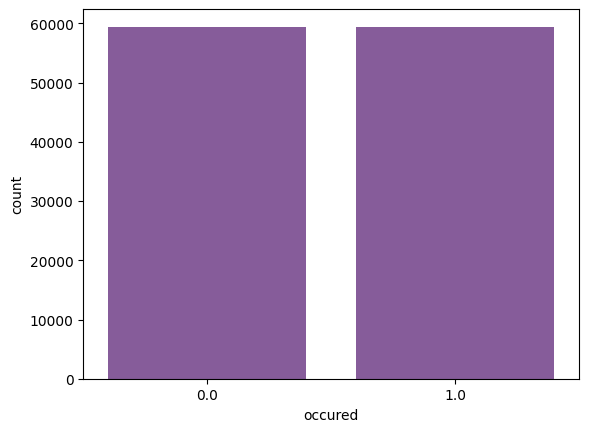

In [11]:
sns.countplot(data=fire_df, x='occured', color=plt.cm.BuPu(0.7))

In [4]:
# Definimos las columnas de features:
columnas = fire_df.columns.tolist()
X = fire_df.drop(columns=["occured"])

# La columna Target:
y = fire_df['occured']

# Y realizamos la división en dos datasets:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [4]:
# Guardamos los nuevos dataframes:

guardar_dataset(X_train, "train_raw")
guardar_dataset(X_test, "test_raw")

Dataset guardado en: src/data_sample\train_raw.csv (95086 filas, 16 columnas)
Dataset guardado en: src/data_sample\test_raw.csv (23772 filas, 16 columnas)


'src/data_sample\\test_raw.csv'

### **2. EDA dirigido ✓**

El **objetivo** de esta sección será explorar los datos de `X_train` para identificar qué variables pueden ser más útiles en base a la relación entre ellas y con el target.

Como la feature `frp` es una variable numérica que determina la intensidad del fuego producido una vez ocurre, no se trata de un dato utilizable para predecir los casos, por lo que debemos eliminarla del dataset para entrenar el modelo. Se decide eliminar antes de aplicar el EDA ya que no va a aportar nada al análisis.

In [5]:
X_train_copy = X_train.drop(columns="frp")

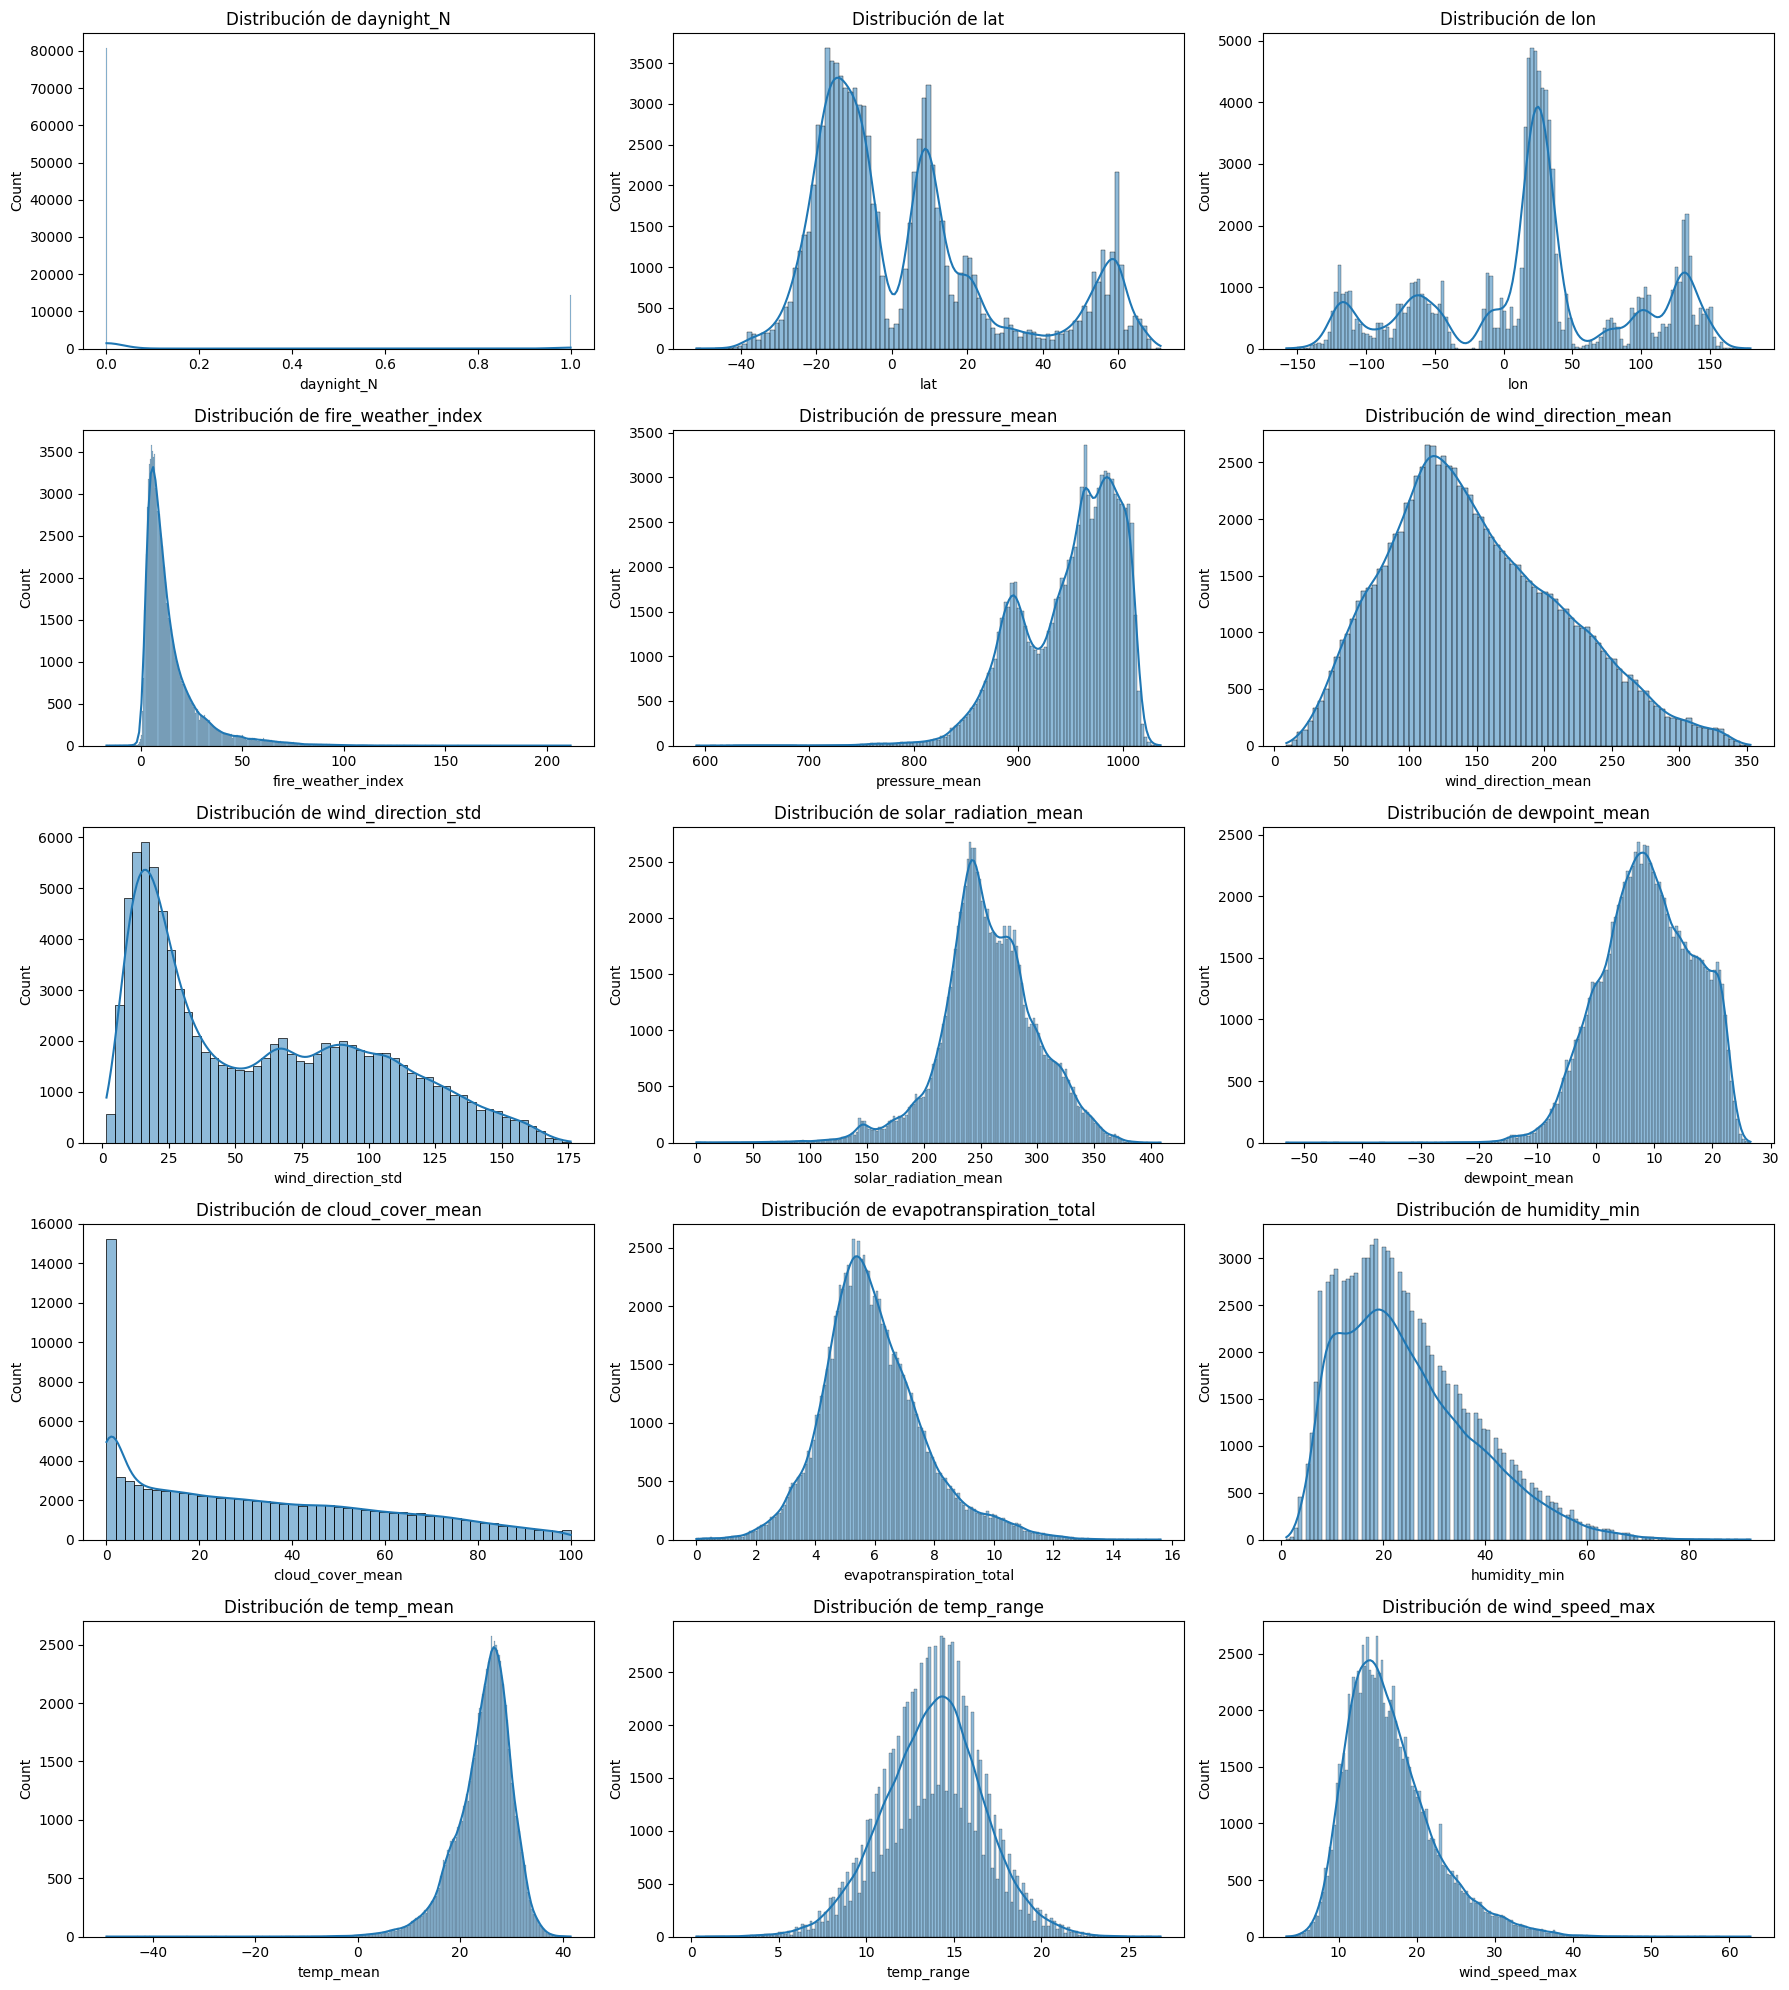

In [ ]:
# Graficar las distribuciones de las features de 'X_train'
plot_distribuciones(X_train_copy)


Vemos que no todas las features siguen una distribución normal, al igual que no todas se encuentran en el mismo rango de valores. También vemos que hay muchos más registros de noche que de día para la feature 'daynight_N'. Ahora comprobemos la distribución en base a la variable target.

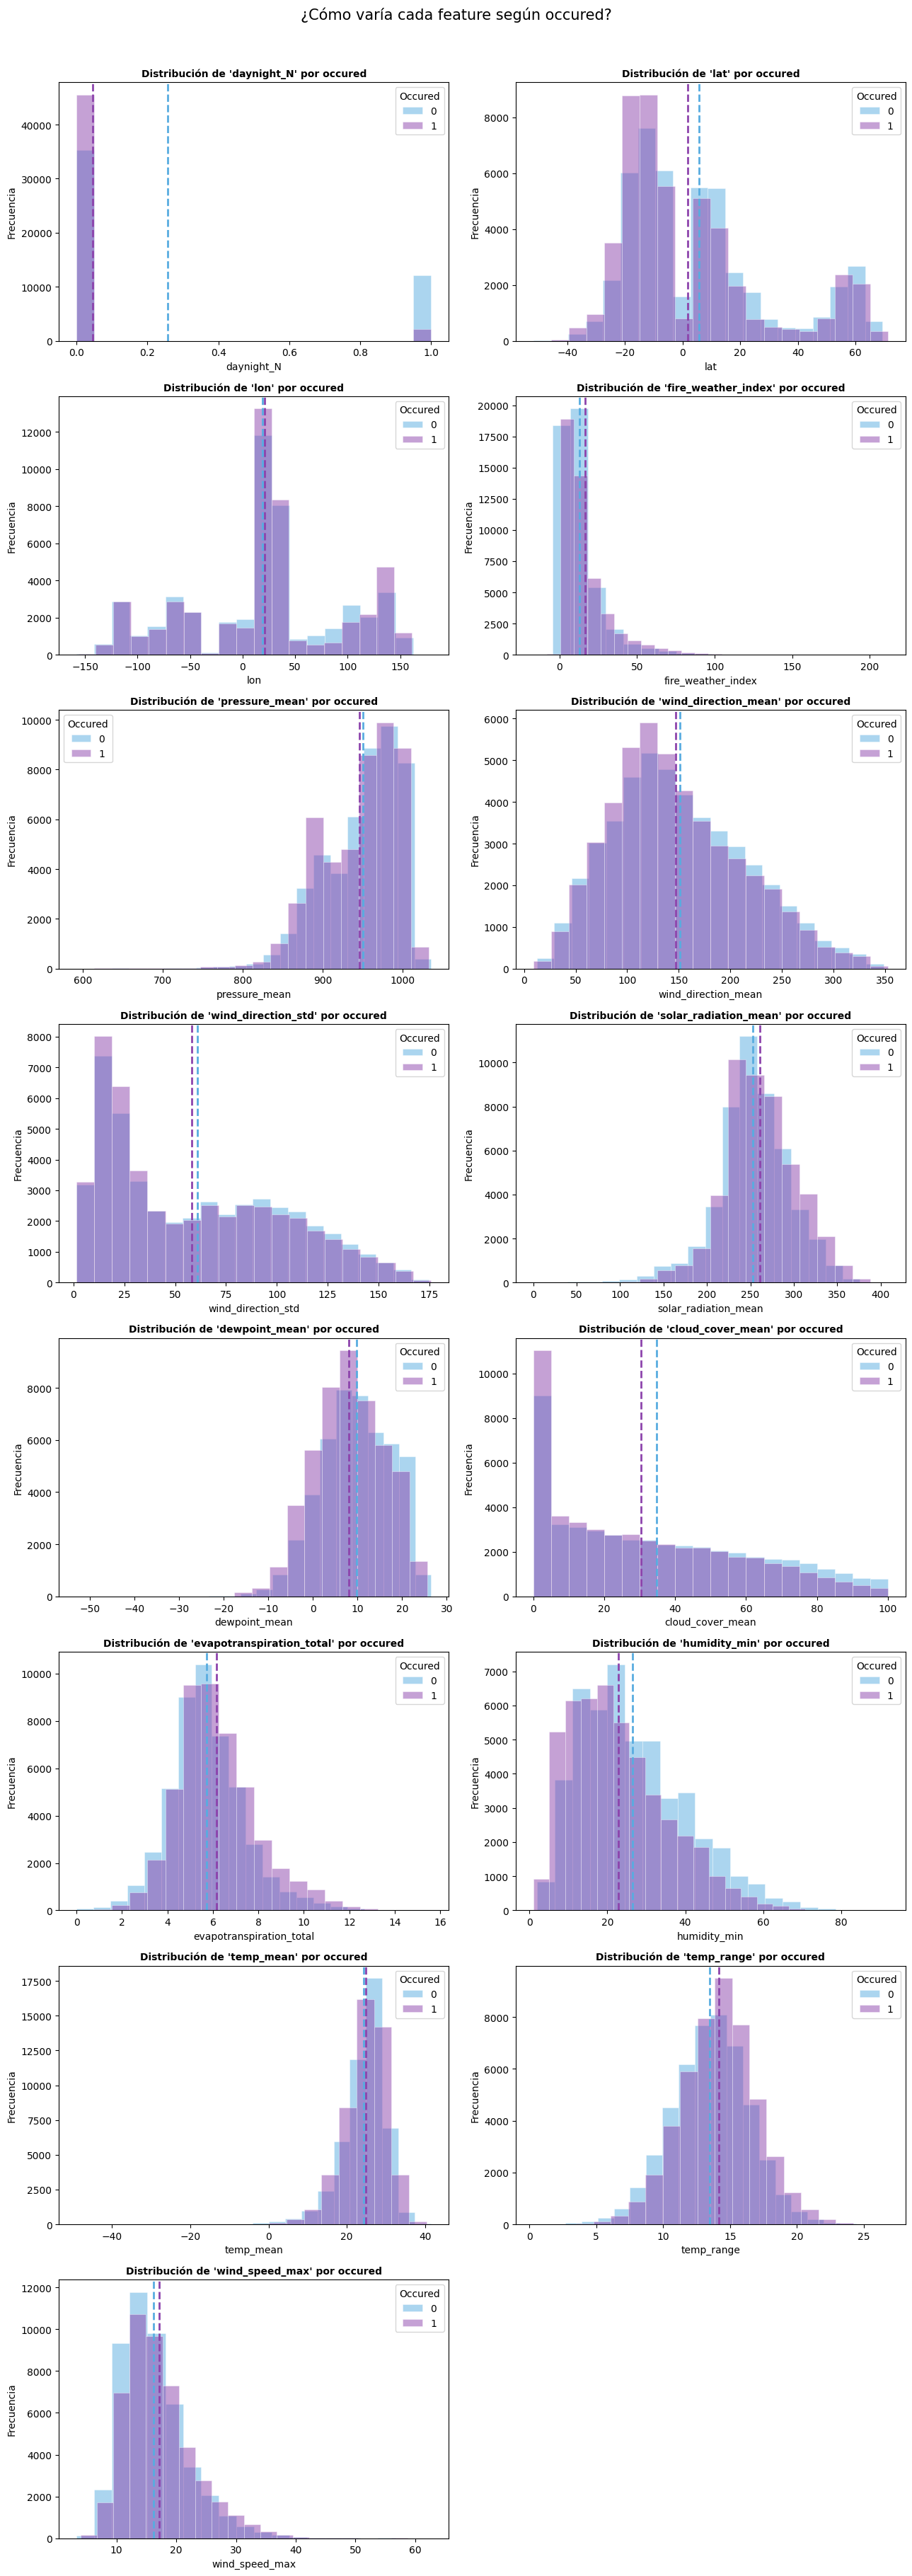

In [7]:
plot_distribuciones_por_clase(X_train_copy, y_train, target_name="occured")

Vemos que la ditribución de los rangos de valores no presentan una división clara entre los dos niveles de `occured`, a excepción de `daynight_N`, donde la mayor parte de casos registrados durante la noche se corresponden con fuegos, mientras que la mayor parte de casos ocurridos durante el día se corresponden con casos de no incendio. Para confirmar que las variables escogidas aportan datos de valor al modelo para diferenciar entre los dos niveles del target, aplicamos T-Test como medida de la significancia estadística.

In [11]:
clases = y_train.unique()

for col in X_train_copy.columns:
        grupo_0 = X_train[col][y_train == clases[0]]
        grupo_1 = X_train[col][y_train == clases[1]]
        
        t_stat, p = ttest_ind(grupo_0, grupo_1)
        print(f"{col}: t={t_stat:.2f}, p-valor={p:.5f}")

daynight_N: t=95.61, p-valor=0.00000
lat: t=23.72, p-valor=0.00000
lon: t=-5.22, p-valor=0.00000
fire_weather_index: t=-39.18, p-valor=0.00000
pressure_mean: t=13.78, p-valor=0.00000
wind_direction_mean: t=10.19, p-valor=0.00000
wind_direction_std: t=10.46, p-valor=0.00000
solar_radiation_mean: t=-32.36, p-valor=0.00000
dewpoint_mean: t=31.61, p-valor=0.00000
cloud_cover_mean: t=24.88, p-valor=0.00000
evapotranspiration_total: t=-40.31, p-valor=0.00000
humidity_min: t=42.32, p-valor=0.00000
temp_mean: t=-11.97, p-valor=0.00000
temp_range: t=-36.56, p-valor=0.00000
wind_speed_max: t=-27.08, p-valor=0.00000


Vemos que para ambos niveles todas las variables presentan diferencias significativas (p-valor < 0.05) entre los registros de incendio y de normalidad, por lo que de momento conservamos toddas las variables. Pasemos ahora a analizar las correlaciones de los datos.

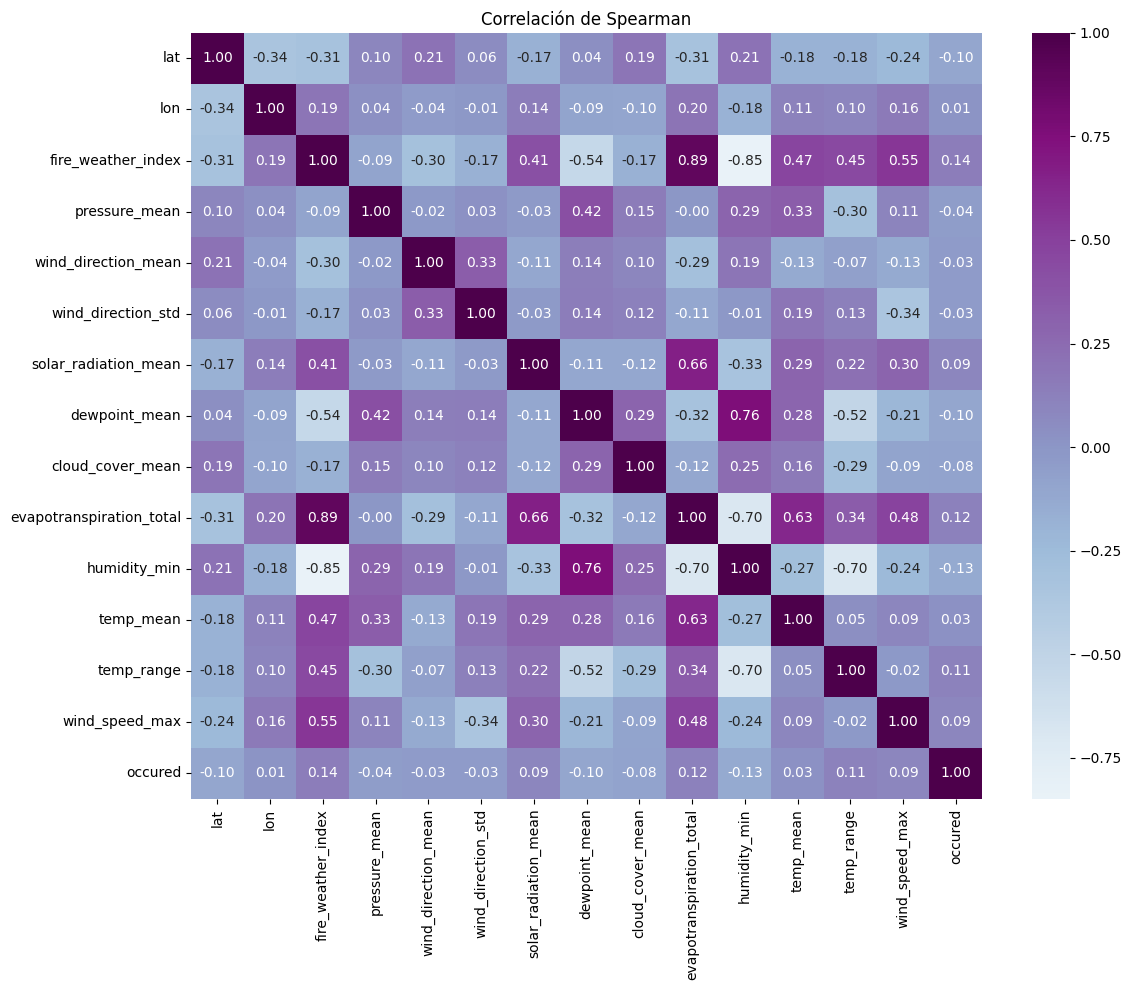

In [5]:
plot_correlacion(X_train_copy, y_train, target_name="occured", excluir="daynight_N")

La variable de evapotranspiration_total está correlacionada con la variable de `fire_weather_index`, `solar_radiation_mean`, `humidity_min` y `temp_mean`, por lo que consideramos eliminarla del dataset. Eliminamos también humidity_min al estar correlacionada con otras dos variables.

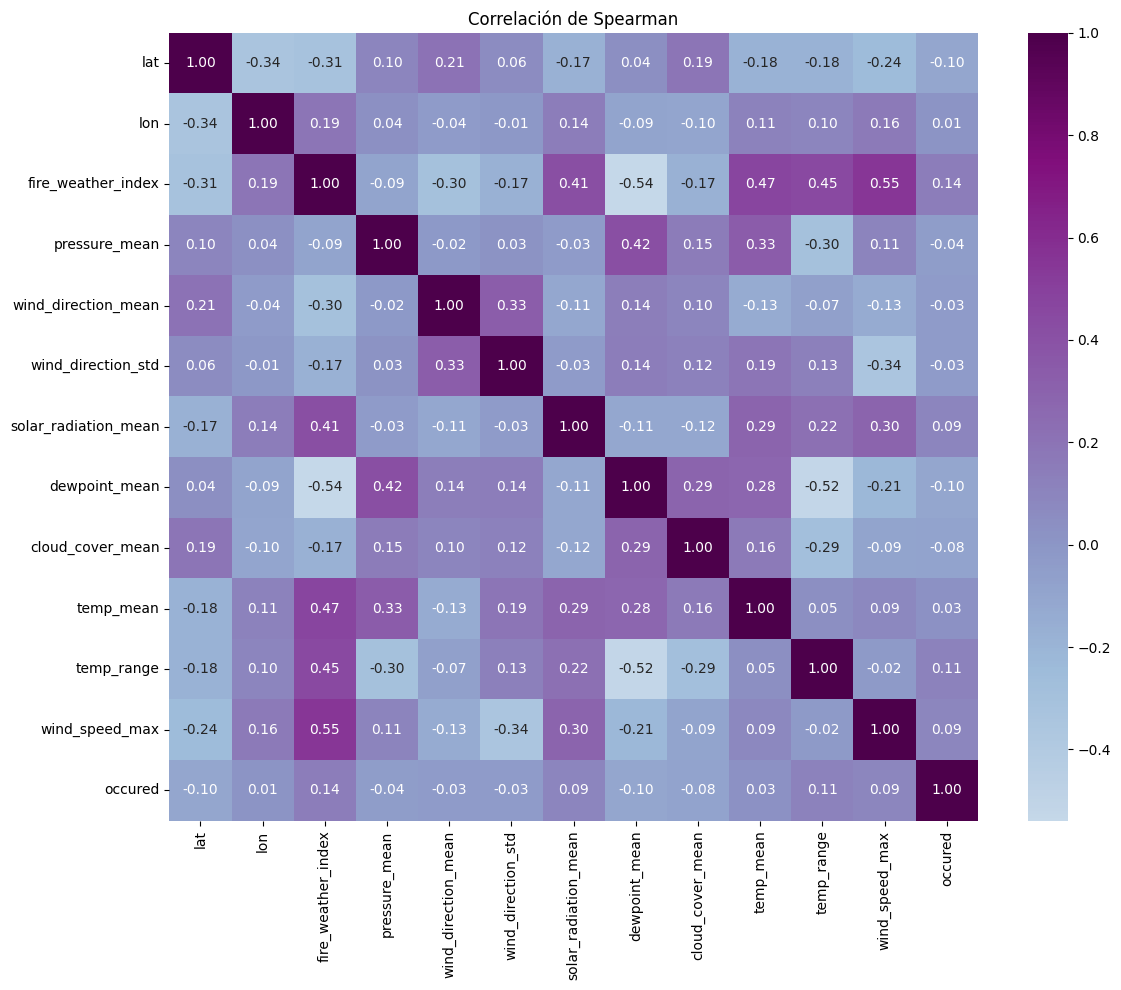

In [6]:
X_train_copy = X_train_copy.drop(columns= ["humidity_min", "evapotranspiration_total"])

plot_correlacion(X_train_copy, y_train, target_name="occured", excluir="daynight_N")

Las correlaciones mostradas ahoras están por debajo de 0.80 (no son correlaciones fuertes), por lo que podemos continuar con el análisis de outliers.

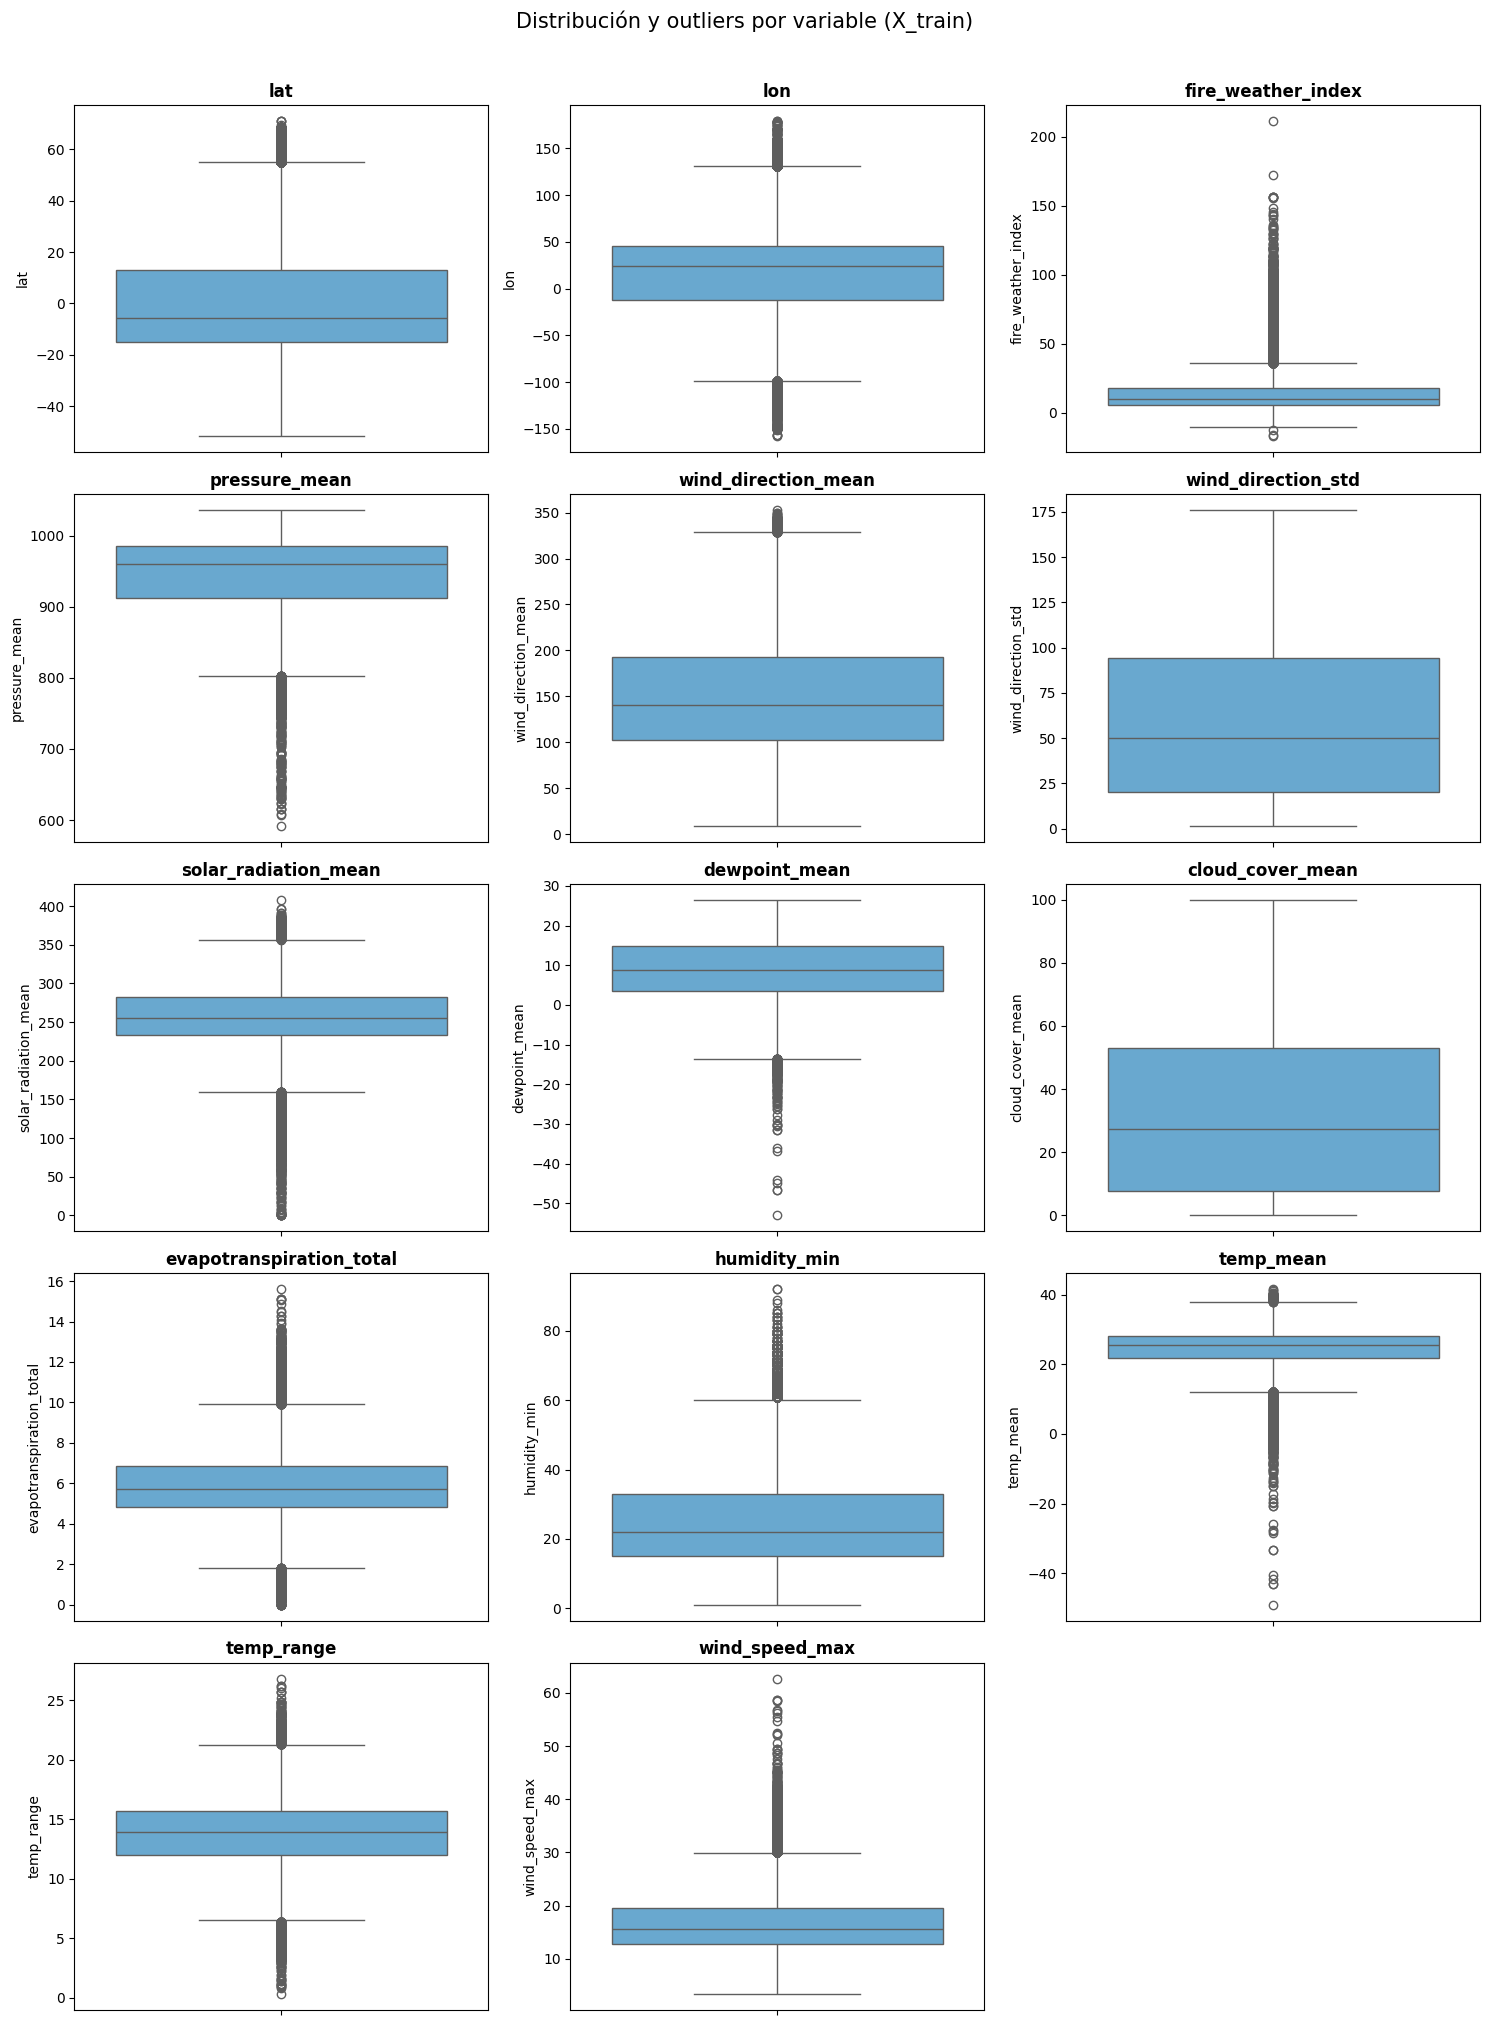

In [18]:
plot_boxplots(X_train_copy.drop(columns="daynight_N"), titulo="Distribución y outliers por variable (X_train)")

Dado que sí contamos con una presencia significativa de outliers, tendremos que elegir modelos que no sean muy sensibles a su presencia o transformar los datos para pasarlos por modelos que sí se vean afectados por estas condiciones. Realizaremos en el apartado 4 de este notebook una estandarización de los datos para guardarlos en una versión alternativa de X_train, para para tenerla preparada cuando se realice el estudio del baseline del modelo.

### **3. Feature Engineering ✓**

Para este trabajo **no** se crean nuevas variables. Ver notebook `feature_engineering.ipynb` para más información.

### **4. Preprocesado ✓**

El **objetivo** de esta sección será crear una copia de `X_train` procesada para tratar las distribuciones sesgadas de algunas variables que vimos en el apartado 2 y con un procesado de los outliers. De esta manera se podrá utilizar cuando establezcamos baselines de modelos lineales. También crearemos una copia de y_test sin las variables que hemos descartado del dataset original por su correlación con otras features.

Para ello, elegimos `PowerTransformer` dentro de la librería de sklern.preprocessing, pues busca estabilizar la varianza y hacer que los datos se parezcan lo máximo posible a una ditribución normal, transformado de manera específica cada una de las columnas (features) según su distribución.

Se elige además el método de Yeo-Johnson porque admite valores negativos, ceros y positivos (presentes en los datos en features como `lon`, `lat` o `dewpoint_mean`).

In [14]:
# Importamos la librería elegida
from sklearn.preprocessing import PowerTransformer

In [15]:
X_train_scaled = X_train_copy.copy()

# Se crea una variable para que la columna categórica 'daynight_N'no entre en la transformación y otra con las columnas continuas
col_categorica = "daynight_N"
columnas_continuas = [c for c in X_train_scaled.columns if c != col_categorica]

# Se aplica la transformación de los datos mediant PowerTransformer
spt = PowerTransformer(method="yeo-johnson", standardize=True) 

X_train_scaled[columnas_continuas] = spt.fit_transform(X_train_scaled[columnas_continuas])

Comprobamos que existen cambios en `X_train_scaled` y que la dispersión de los datos se ha reducido.

In [10]:
X_train_scaled.head()

,daynight_N,lat,lon,fire_weather_index,pressure_mean,wind_direction_mean,wind_direction_std,solar_radiation_mean,dewpoint_mean,cloud_cover_mean,temp_mean,temp_range,wind_speed_max
43213,0.0,0.500266,0.042436,2.362052,0.193286,-0.234382,1.023322,0.464192,-0.857211,1.052178,2.039546,1.146858,1.256964
84063,0.0,-1.068777,1.522983,1.409680,1.112208,-0.327212,-1.252616,-0.998029,-0.964133,0.014699,-0.306474,-0.823941,1.731070
44909,1.0,-0.581959,0.172791,-0.331431,0.334480,-0.450192,0.309297,-0.007010,0.570590,0.072837,0.353678,-0.168571,0.485172
71721,0.0,1.359277,-1.419045,-1.175020,0.841019,-0.765510,-0.947565,0.778103,-0.820690,0.875908,-1.990093,0.786644,-0.475380
28676,0.0,0.532232,-1.239781,-1.146890,1.250837,0.188794,0.502953,0.312456,1.997179,1.418256,0.768440,-1.296800,-1.339320


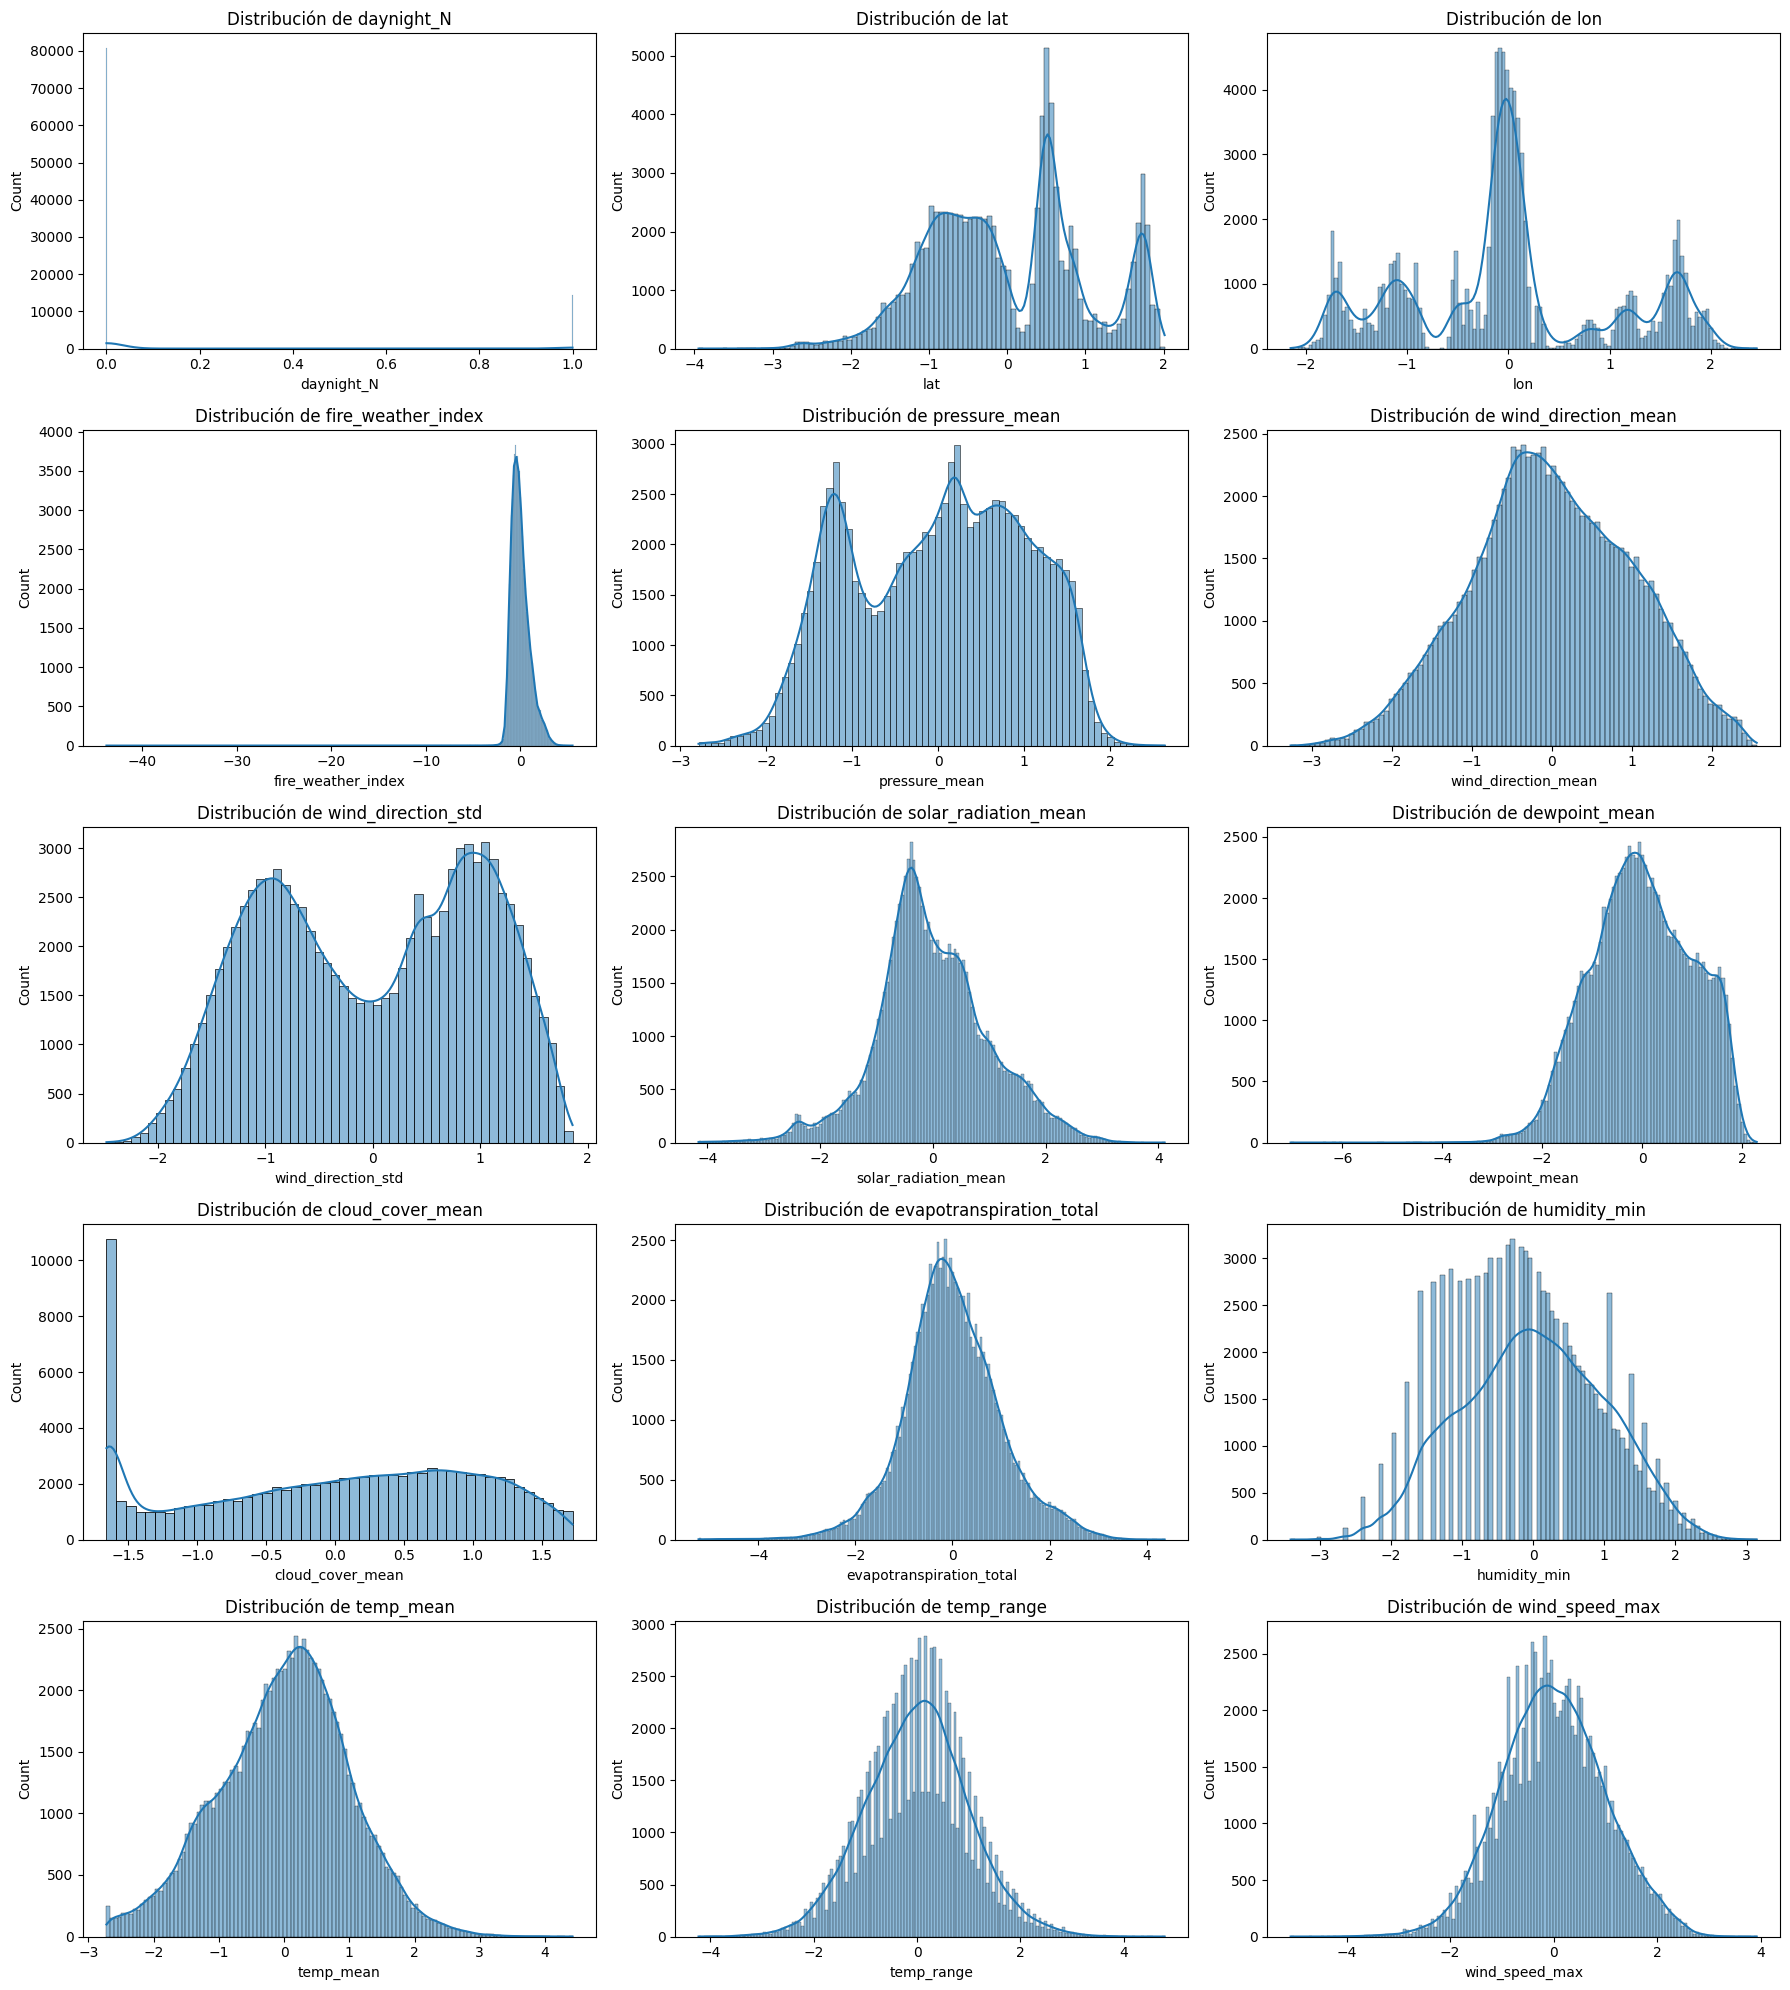

In [16]:
plot_distribuciones(X_train_scaled)

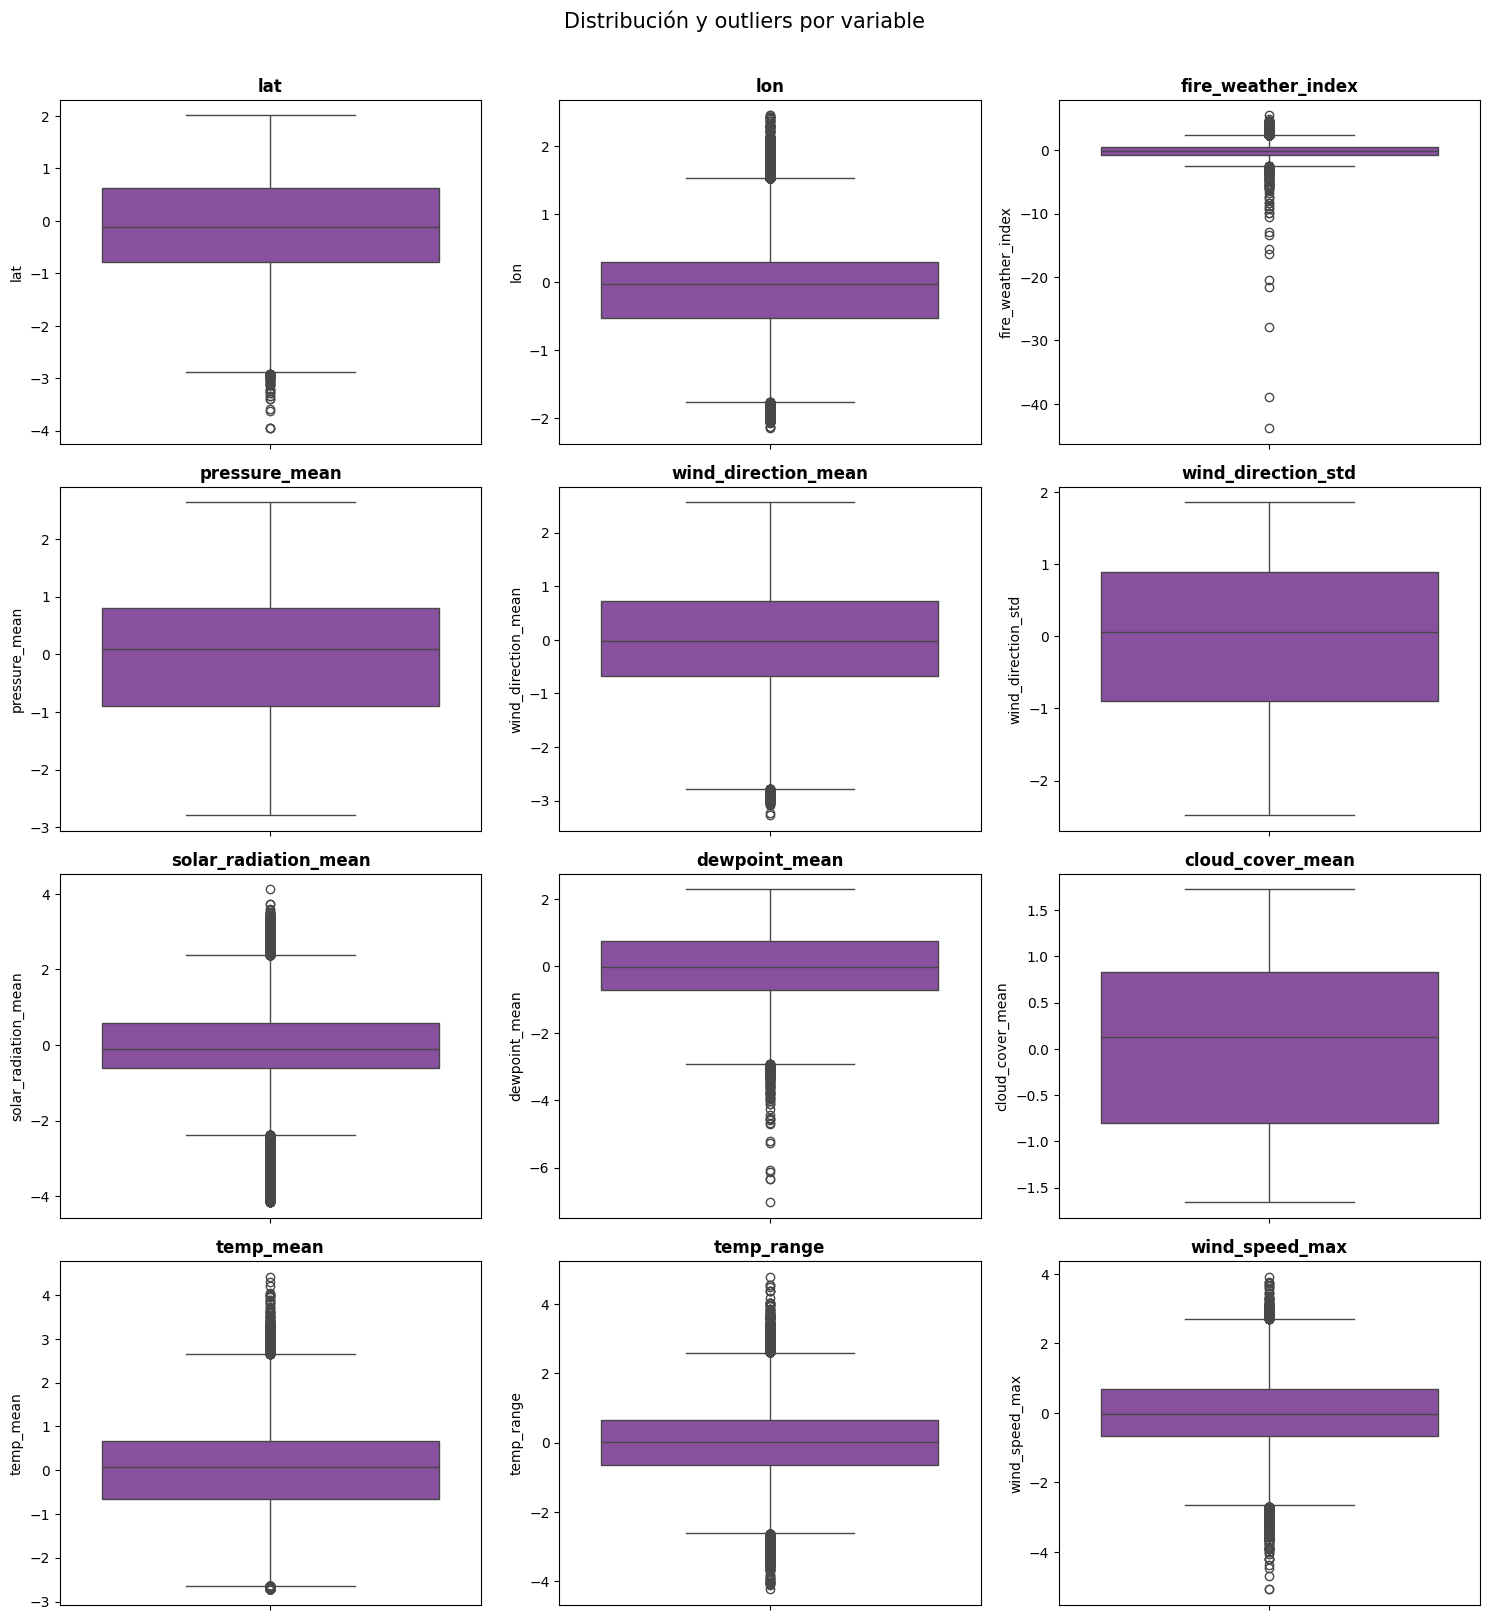

In [16]:
plot_boxplots(X_train_scaled.drop(columns="daynight_N"), color="#8D44AC")

Para comprobar que en efecto el tratamiento de outliers ha sido efectivo, vamos a calcular el **coeficiente de asimetría (skewness)**,  que busca cuantificar cuánto se desvía la distribución de una variable respecto a una forma simétrica De esta forma:

- **Skew ≈ 0** → distribución aproximadamente simétrica (similar a una normal)
- **Skew > 0** → cola larga hacia la derecha (valores atípicos altos "estiran" la distribución)
- **Skew < 0** → cola larga hacia la izquierda (valores atípicos bajos "estiran" la distribución)
- **|Skew| > |2|** → distribución muy asimétrica, con presencia de valores extremos que se alejan mucho del grueso de los datos

In [ ]:
# Aplicamos el método .skew() de pandas
for col in X_train_scaled.columns:
    skew_antes = X_train_copy[col].skew()
    skew_despues = X_train_scaled[col].skew()
    print(f"{col}: Antes={skew_antes:.2f} | Después={skew_despues:.2f}")

daynight_N: Antes=1.96 | Después=1.96
lat: Antes=1.03 | Después=0.07
lon: Antes=-0.15 | Después=0.21
fire_weather_index: Antes=2.57 | Después=-1.39
pressure_mean: Antes=-0.93 | Después=-0.14
wind_direction_mean: Antes=0.47 | Después=-0.03
wind_direction_std: Antes=0.54 | Después=-0.09
solar_radiation_mean: Antes=-0.36 | Después=0.06
dewpoint_mean: Antes=-0.24 | Después=-0.14
cloud_cover_mean: Antes=0.55 | Después=-0.25
temp_mean: Antes=-1.19 | Después=-0.12
temp_range: Antes=-0.09 | Después=0.02
wind_speed_max: Antes=1.09 | Después=0.00


Vemos que todos los valores obtenidos tras la normalización se encuentran cerca de cero, por lo que consideramos que la transformación de los datos ha sido efectiva. Procedemos a guardar esta versión escalada de los datos, junto con la versión con el filtrado de variables. También creamos un archivo sin las features seleccionadas para `X_test`.

In [12]:
X_test_filtered = X_test.drop(columns=["humidity_min", "evapotranspiration_total", "frp"])

In [86]:
guardar_dataset(X_train_scaled, "train_scaled")
guardar_dataset(X_train_copy, "train_filtered")
guardar_dataset(X_test_filtered, "test_filtered")
guardar_dataset(y_train, "y_train")
guardar_dataset(y_test, "y_test")

Dataset guardado en: src/data_sample\train_scaled.csv (95086 filas, 13 columnas)
Dataset guardado en: src/data_sample\train_filtered.csv (95086 filas, 13 columnas)
Dataset guardado en: src/data_sample\test_filtered.csv (23772 filas, 13 columnas)
Dataset guardado en: src/data_sample\y_train.csv (95086 filas, 1 columnas)
Dataset guardado en: src/data_sample\y_test.csv (23772 filas, 1 columnas)


'src/data_sample\\y_test.csv'

### **5. Modelado ✓**

El **objetivo** de esta sección será establecer un modelo baseline a partir del cual realizar una optimización de hiperparámetros.

#### **5.1 Justificación de las métricas de evaluación y de los umbrales mínimos de rendimiento**

Dado que el objetivo del modelo es predecir la **ocurrencia de incendios forestales**, una tarea de clasificación binaria con implicaciones directas sobre la seguridad y la gestión de recursos, la elección de las métricas de evaluación no puede basarse únicamente en la **accuracy**. Esta métrica, aunque intuitiva, puede resultar engañosa en problemas donde el coste de los distintos tipos de error no es simétrico — un modelo que acierte mucho en términos globales puede, aun así, estar fallando sistemáticamente en identificar los casos que más importan.

Por ello, se han priorizado las siguientes métricas:

- **Recall (sensibilidad) de la clase positiva**: mide qué proporción de incendios reales el modelo consigue detectar. Es la métrica más crítica del proyecto, ya que un **falso negativo** (no detectar un incendio que sí ocurre) tiene un coste potencialmente mucho mayor que un falso positivo — implica no activar protocolos de prevención o respuesta ante una situación de riesgo real.

- **Precisión de la clase positiva**: mide qué proporción de las alertas generadas por el modelo corresponden realmente a incendios. Es relevante porque un exceso de falsos positivos puede generar sobrecarga operativa (activación de recursos innecesarios) y, a largo plazo, pérdida de confianza en el sistema de alerta.

- **F1-score**: se utiliza como métrica de equilibrio entre ambas, especialmente durante la fase de optimización de hiperparámetros, para evitar que el modelo se especialice excesivamente en una de las dos a costa de la otra.

- **Recall de la clase negativa**: aunque el foco principal está en detectar incendios, un modelo que clasifique como "riesgo de incendio" prácticamente cualquier caso (sacrificando por completo la clase negativa) no resulta operativamente útil, ya que satura el sistema de alertas y reduce su valor práctico, pues supone un gasto de recursos inviable.

##### Por qué el umbral de > 70% de recall en positivos

Se establece como criterio mínimo aceptable que el modelo detecte correctamente al menos **>70% de los incendios reales**. Este umbral responde a un equilibrio entre:

- La naturaleza crítica de los falsos negativos en este dominio, que justifica exigir un recall elevado.
- El reconocimiento de que un recall del 100% no es realista en un problema con esta complejidad (variabilidad meteorológica, factores no capturados por las variables disponibles, ruido inherente a los datos), por lo que se fija un umbral alcanzable.

##### Por qué el umbral de > 50% de recall en negativos

Se exige que el modelo acierte en más de la mitad de los casos negativos reales como criterio mínimo de utilidad práctica. Este umbral, más permisivo que el de la clase positiva, refleja la asimetría de costes entre ambos tipos de error: se acepta un mayor margen de falsos positivos a cambio de maximizar la detección de incendios reales. Sin embargo, superar el 50% garantiza que el modelo mantiene una capacidad de discriminación real entre clases, evitando el escenario extremo observado durante la experimentación —en el que configuraciones demasiado simples del modelo tendían a clasificar la mayoría de los casos como positivos, con un recall de la clase negativa muy bajo (en torno al 40%), lo cual resulta poco útil en un contexto operativo real.

#### **5.2 Establecimiento del modelo baseline**

Para determinar cuál es el mejor modelo, escogemos 2 tipos de modelos: dos modelos lineales y 4 modelos basados en ensembles de árboles de decisión. Se hace con la intención de abarcar diferentes formas de interpretar los datos.

In [20]:
from sklearn.model_selection import cross_val_score, KFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

In [16]:
# Creamos un diccionario con los modelos seleccionados para el estudio del baseline.
modelos_clasificacion = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,     # estabiliza predicciones sin disparar el tiempo
        max_depth=3,       
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,     
        learning_rate=0.1,    # default razonable
        max_depth=3,          
        random_state=42,
        n_jobs=-1,
        verbosity=0           # silencia los logs de XGBoost
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,     # mismo criterio que XGBoost
        learning_rate=0.1,    # mismo criterio que XGBoost
        num_leaves=31,        # default de LightGBM, conservador
        random_state=42,
        n_jobs=-1,
        verbose=-1            # silencia los logs
    ),

    "GradientBoostingClassifier": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbose=0, 
    )
}
# Separamos logistic regression porque va a usar el dataset estandarizado y con tratamiento de outliers.
modelos_standarizables = {
    "clf": LogisticRegression(
        max_iter=1000, 
        random_state=42 
    ),    
    "knn" : KNeighborsClassifier(
        n_neighbors=3, # Default razonable
    )
}

In [21]:
# Usamos KFold para dividir los datos en 5 folds mezclados aleatoriamente (para evitar sesgos por orden), 
# con semilla fija para reproducibilidad
cv_clf = KFold(n_splits=5, shuffle=True, random_state=42)  

In [19]:
# EVALUACIÓN CLASIFICACIÓN DE MODELOS BASADOS EN ENSEMBLES
print("=" * 55)
print("BASELINE CLASIFICACIÓN DE MODELOS BASADOS EN ENSEMBLES")
print("=" * 55)
for nombre, modelo in modelos_clasificacion.items():
    resultado = cross_validate(modelo, X_train_copy, y_train, cv=cv_clf, 
                                scoring=["accuracy", "precision", "recall", "f1"])
    print(f"{nombre:<22} "
          f"recall: {resultado['test_recall'].mean():.4f} ± {resultado['test_recall'].std():.4f} | "
          f"precision: {resultado['test_precision'].mean():.4f} | "
          f"f1: {resultado['test_f1'].mean():.4f} | "
          f"accuracy: {resultado['test_accuracy'].mean():.4f} | "
          )


# EVALUACIÓN CLASIFICACIÓN DE MODELOS BASADOS EN DISTANCIAS
print("=" * 55)
print("BASELINE CLASIFICACIÓN DE MODELOS BASADOS EN DISTANCIAS")
print("=" * 55)

for nombre, modelo in modelos_standarizables.items():
    resultado = cross_validate(modelo, X_train_scaled, y_train, cv=cv_clf, 
                                scoring=["accuracy", "precision", "recall", "f1"])
    print(f"{nombre:<22} "
          f"recall: {resultado['test_recall'].mean():.4f} ± {resultado['test_recall'].std():.4f} | "
          f"precision: {resultado['test_precision'].mean():.4f} | "
          f"f1: {resultado['test_f1'].mean():.4f} | "
          f"accuracy: {resultado['test_accuracy'].mean():.4f} | "
          )

BASELINE CLASIFICACIÓN DE MODELOS BASADOS EN ENSEMBLES
Random Forest          recall: 0.7810 ± 0.0060 | precision: 0.6030 | f1: 0.6805 | accuracy: 0.6325 | 
XGBoost                recall: 0.7654 ± 0.0047 | precision: 0.6174 | f1: 0.6835 | accuracy: 0.6446 | 
LightGBM               recall: 0.7661 ± 0.0040 | precision: 0.6263 | f1: 0.6892 | accuracy: 0.6536 | 
GradientBoostingClassifier recall: 0.7615 ± 0.0056 | precision: 0.6183 | f1: 0.6825 | accuracy: 0.6449 | 
BASELINE CLASIFICACIÓN DE MODELOS BASADOS EN DISTANCIAS
clf                    recall: 0.7630 ± 0.0033 | precision: 0.6024 | f1: 0.6733 | accuracy: 0.6288 | 
knn                    recall: 0.6593 ± 0.0034 | precision: 0.6105 | f1: 0.6339 | accuracy: 0.6184 | 


**Justificación del enfoque de ensemble (Voting Classifier)**

Los resultados del baseline muestran una convergencia notable en el rendimiento de los modelos evaluados, independientemente de su naturaleza algorítmica:

- **Modelos basados en ensembles de árboles** (Random Forest, XGBoost, LightGBM, GradientBoostingClassifier): F1 en el rango de 0.6805–0.6892, con recall entre 0.7615–0.7810.
- **Modelos basados en distancias** (Regresión Logística, KNN): F1 en el rango de 0.6339–0.6733.

La baja dispersión entre los F1-scores de los modelos de ensemble (Δ ≈ 0.009) sugiere que estos han alcanzado un techo de rendimiento similar dada la información disponible en el conjunto de features actual, con diferencias marginales atribuibles a particularidades de cada algoritmo más que a una superioridad estructural de uno sobre otro. Aunque los modelos basados en distancias presentan un rendimiento individual algo inferior, sus predicciones se fundamentan en un mecanismo de decisión sustancialmente distinto —proximidad en el espacio de features frente a particiones jerárquicas del espacio de decisión—, lo que los convierte en candidatos con potencial de aportar información complementaria y **poco correlacionada** con la de los modelos basados en árboles.

Partiendo de esta observación, se decide construir un modelo de **ensemble por votación (Voting Classifier)** que combine ambas familias de algoritmos. El fundamento teórico de esta decisión es que, al promediar las predicciones de modelos con mecanismos de aprendizaje diversos y errores no perfectamente correlacionados, el ensemble resultante puede lograr una mejora en la capacidad de generalización superior a la de cualquier modelo individual, incluso cuando estos presentan rendimientos similares entre sí de forma aislada.

### **6. Optimización ✓**

**6.1 Optimización del modelo LightGBM**

El **objetivo** de esta sección es optimizar el modelo de lightGBM para conseguir el máximo nivel de recall de los casos positivos, sin olvidar los casos negativos. 

In [20]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve, RocCurveDisplay

In [ ]:
# Instanciamos el modelo
lgbm_clas = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)


In [30]:
# --- Etapa 1: búsqueda amplia ---
param_grid = {
    'n_estimators': [80, 150, 250],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7, -1],
    'num_leaves': [8, 15, 31, 63],
    'max_bins': [280, 310],
}
lgbm_grid = GridSearchCV(lgbm_clas, cv=5, param_grid=param_grid, scoring="f1", n_jobs=-1)
lgbm_grid.fit(X_train_copy, y_train)
print(lgbm_grid.best_score_, lgbm_grid.best_params_)

0.6920526466819863 {'learning_rate': 0.05, 'max_bins': 280, 'max_depth': -1, 'n_estimators': 150, 'num_leaves': 63}


In [32]:
# --- Etapa 2: refinamiento iterativo, acotando el rango en cada ronda ---
# Punto de partida: el mejor resultado de la Etapa 1
best_params = lgbm_grid.best_params_
best_score = -np.inf          # inicializado en -infinito para que la primera ronda siempre cuente como "mejora"
paso_relativo = 0.3           # margen inicial de exploración: ±30% alrededor del valor actual de cada hiperparámetro
n_rondas = 10                 # nº máximo de rondas de mejora
tolerancia_mejora = 0.001     # si la mejora entre rondas es menor a esto, 
                             #se considera que se alcanzó el máximo de mejora


for ronda in range(1, n_rondas + 1):

    # Para cada hiperparámetro, se genera un grid de 3 valores centrados en el mejor
    # valor actual: uno por debajo, el valor actual, y uno por encima (según paso_relativo)

    lr = best_params['learning_rate']
    grid_learning_rate = sorted(set([round(max(0.01, lr*(1-paso_relativo)), 4), lr, round(lr*(1+paso_relativo), 4)]))
    # max(0.01, ...) evita que learning_rate baje a 0 o negativo

    mb = best_params['max_bins']
    grid_max_bins = sorted(set([max(10, int(mb*(1-paso_relativo))), mb, int(mb*(1+paso_relativo))]))
    # max(10, ...) evita bins demasiado bajos; int() porque max_bins debe ser entero

    md = best_params['max_depth']
    # max_depth=-1 significa "sin límite" en LightGBM, así que no se puede escalar proporcionalmente
    # (-1 * 1.3 no tiene sentido), po lo que se compara explícitamente contra dos valores concretos
    grid_max_depth = [-1, 10, 15] if md == -1 else sorted(set([max(2, md-1), md, md+1]))

    ne = best_params['n_estimators']
    grid_n_estimators = sorted(set([max(10, int(ne*(1-paso_relativo))), ne, int(ne*(1+paso_relativo))]))

    nl = best_params['num_leaves']
    grid_num_leaves = sorted(set([max(2, int(nl*(1-paso_relativo))), nl, int(nl*(1+paso_relativo))]))

    param_grid = {
        'learning_rate': grid_learning_rate, 'max_bins': grid_max_bins,
        'max_depth': grid_max_depth, 'n_estimators': grid_n_estimators, 'num_leaves': grid_num_leaves,
    }

    # Se ejecuta un GridSearchCV nuevo en cada ronda, sobre el grid estrechado de esa ronda
    grid_search = GridSearchCV(LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
                                param_grid=param_grid, scoring="f1", cv=5, n_jobs=-1)
    grid_search.fit(X_train_copy, y_train)

    nuevo_score = grid_search.best_score_
    mejora = nuevo_score - best_score
    print(f"Ronda {ronda}: score={nuevo_score:.4f} (mejora: {mejora:+.4f}) | params={grid_search.best_params_}")

    # Condición de parada: si la mejora respecto a la ronda anterior es insignificante,
    # se asume que ya se alcanzó el óptimo y no merece la pena seguir refinando
    mejora_detectada = mejora < tolerancia_mejora and ronda > 1
    best_score = nuevo_score
    best_params = grid_search.best_params_
    paso_relativo *= 0.6

    # --- Comprueba la condición de parada después de actualizar las variables---
    if mejora_detectada:
        print(f"Convergencia alcanzada en ronda {ronda}")
        break

print("\nBest params:", best_params, "| Best score:", best_score)

Ronda 1: score=0.6935 (mejora: +inf) | params={'learning_rate': 0.05, 'max_bins': 280, 'max_depth': -1, 'n_estimators': 195, 'num_leaves': 81}
Ronda 2: score=0.6936 (mejora: +0.0002) | params={'learning_rate': 0.041, 'max_bins': 280, 'max_depth': -1, 'n_estimators': 195, 'num_leaves': 95}
Convergencia alcanzada en ronda 2

Best params: {'learning_rate': 0.041, 'max_bins': 280, 'max_depth': -1, 'n_estimators': 195, 'num_leaves': 95} | Best score: 0.6936440956444682


recall: 0.7687 | precision: 0.6294 | f1: 0.6921 | accuracy: 0.6572
              precision    recall  f1-score   support

         0.0       0.71      0.54      0.61     11979
         1.0       0.62      0.77      0.69     11793

    accuracy                           0.66     23772
   macro avg       0.67      0.66      0.65     23772
weighted avg       0.67      0.66      0.65     23772



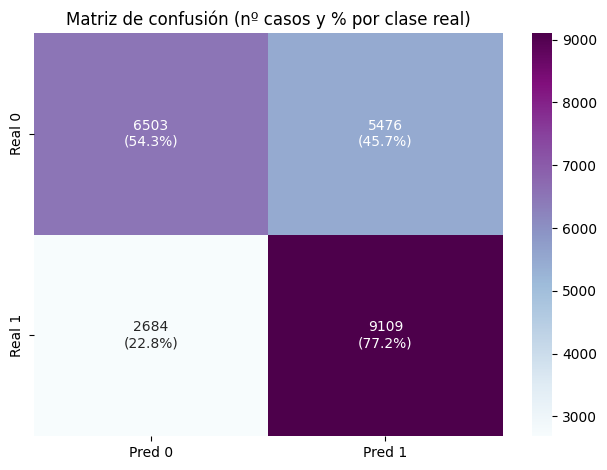

In [ ]:
lgbm_final_op2 = LGBMClassifier(
    n_estimators=195, learning_rate=0.041, max_depth=-1, num_leaves=81, max_bins=280,
    random_state=42, n_jobs=-1, verbose=-1
)

resultado_final_2 = cross_validate(
    lgbm_final_op2, X_train_copy, y_train, cv=10,
    scoring=["accuracy", "precision", "recall", "f1"]
)
print(f"recall: {resultado_final_2['test_recall'].mean():.4f} | "
      f"precision: {resultado_final_2['test_precision'].mean():.4f} | "
      f"f1: {resultado_final_2['test_f1'].mean():.4f} | "
      f"accuracy: {resultado_final_2['test_accuracy'].mean():.4f}")

lgbm_final_op2.fit(X_train_copy, y_train)
y_pred2 = lgbm_final_op2.predict(X_test_filtered)
print(classification_report(y_test, y_pred2))

# Representamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred2)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

etiquetas = np.array([f"{v}\n({p:.1f}%)" for v, p in zip(cm.flatten(), cm_pct.flatten())]).reshape(cm.shape)

sns.heatmap(cm, annot=etiquetas, fmt="", cmap="BuPu", xticklabels=["Pred 0", "Pred 1"], yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de confusión (nº casos y % por clase real)")
plt.tight_layout()
plt.show()

**Reducción de falsos positivos (regularización)**

Se intenta mejorar aún más el modelo de la Fase 2, manteniendo fijos sus hiperparámetros ya optimizados y explorando parámetros de regularización (`min_child_samples`, `min_split_gain`, `reg_alpha`, `reg_lambda`) orientados específicamente a reducir los falsos positivos, optimizando ahora por **precisión**.

In [34]:
# Hiperparámetros ya optimizados en la Fase 2 (scoring f1) — se mantienen fijos
# en esta fase, ya que el objetivo aquí es afinar únicamente la regularización
# para reducir falsos positivos, sin volver a tocar la arquitectura del modelo
parametros_fijos = {
    'n_estimators': 195, 'learning_rate': 0.041, 'max_depth': -1, 'num_leaves': 81, 'max_bins': 280,
    'random_state': 42, 'n_jobs': -1, 'verbose': -1
}

# Punto de partida: los valores por defecto de LightGBM para los 4 parámetros
# de regularización que se van a explorar (ninguno de ellos aplica regularización aún)
best_params = {'min_child_samples': 20, 'min_split_gain': 0.0, 'reg_alpha': 0.0, 'reg_lambda': 0.0}

best_score = -np.inf          # para que la primera ronda cuente siempre como mejora
paso_relativo = 0.3           # margen inicial de exploración (30%)
n_rondas = 5
tolerancia_mejora = 0.001

for ronda in range(1, n_rondas + 1):

    # A diferencia del refinamiento de la Fase 2, aquí varios parámetros parten
    # de 0 (min_split_gain, reg_alpha, reg_lambda), donde escalar de forma
    # proporcional no funciona (0 * cualquier cosa sigue siendo 0). Por eso se
    # usa un paso ADITIVO (sumar/restar una cantidad) en vez de multiplicativo.

    # min_child_samples: es entero y no parte de 0 -> paso aditivo basado en su propio valor
    mcs = best_params['min_child_samples']
    paso_mcs = max(5, int(mcs * paso_relativo))  # mínimo de 5 para que el paso no sea insignificante
    grid_min_child_samples = sorted(set([max(5, mcs-paso_mcs), mcs, mcs+paso_mcs]))

    # min_split_gain: puede ser 0 -> paso aditivo fijo, pequeño, escalado por la ronda
    msg = best_params['min_split_gain']
    paso_msg = round(max(0.01, paso_relativo*0.3), 4)  # paso más pequeño porque este parámetro es sensible
    grid_min_split_gain = sorted(set([round(max(0.0, msg-paso_msg), 4), msg, round(msg+paso_msg, 4)]))
    # max(0.0, ...) evita valores negativos, que no tienen sentido para este parámetro

    # reg_alpha (L1): puede ser 0 -> paso aditivo fijo
    ra = best_params['reg_alpha']
    paso_ra = round(max(0.1, paso_relativo), 4)
    grid_reg_alpha = sorted(set([round(max(0.0, ra-paso_ra), 4), ra, round(ra+paso_ra, 4)]))

    # reg_lambda (L2): puede ser 0 -> mismo tratamiento que reg_alpha
    rl = best_params['reg_lambda']
    paso_rl = round(max(0.1, paso_relativo), 4)
    grid_reg_lambda = sorted(set([round(max(0.0, rl-paso_rl), 4), rl, round(rl+paso_rl, 4)]))

    param_grid = {
        'min_child_samples': grid_min_child_samples, 'min_split_gain': grid_min_split_gain,
        'reg_alpha': grid_reg_alpha, 'reg_lambda': grid_reg_lambda,
    }

    # El modelo se construye con **parametros_fijos (arquitectura ya optimizada)
    # + el param_grid de esta ronda (solo regularización)
    # scoring="precision" porque el objetivo específico de esta fase es reducir falsos positivos
    grid_search = GridSearchCV(LGBMClassifier(**parametros_fijos), param_grid=param_grid,
                                scoring="precision", cv=cv_clf, n_jobs=-1)
    grid_search.fit(X_train_copy, y_train)

    # Si la mejora es insignificante, se detiene el refinamiento (convergencia)
    nuevo_score = grid_search.best_score_
    mejora = nuevo_score - best_score
    print(f"Ronda {ronda}: score={nuevo_score:.4f} (mejora: {mejora:+.4f}) | params={grid_search.best_params_}")

    # Condición de parada: si la mejora respecto a la ronda anterior es insignificante,
    # se asume que ya se alcanzó el óptimo y no merece la pena seguir refinando
    best_score = nuevo_score
    best_params = grid_search.best_params_
    paso_relativo *= 0.6

    # --- Comprueba la condición de parada después de actualizar las variables---
    if mejora_detectada:
        print(f"Convergencia alcanzada en ronda {ronda}")
        break

print("\nBest params:", best_params, "| Best score:", best_score)

Ronda 1: score=0.6321 (mejora: +inf) | params={'min_child_samples': 26, 'min_split_gain': 0.0, 'reg_alpha': 0.3, 'reg_lambda': 0.0}
Convergencia alcanzada en ronda 1

Best params: {'min_child_samples': 26, 'min_split_gain': 0.0, 'reg_alpha': 0.3, 'reg_lambda': 0.0} | Best score: 0.6321103060360757


recall: 0.7688 | precision: 0.6300 | f1: 0.6925 | accuracy: 0.6578
              precision    recall  f1-score   support

         0.0       0.71      0.54      0.61     11979
         1.0       0.62      0.77      0.69     11793

    accuracy                           0.66     23772
   macro avg       0.67      0.66      0.65     23772
weighted avg       0.67      0.66      0.65     23772



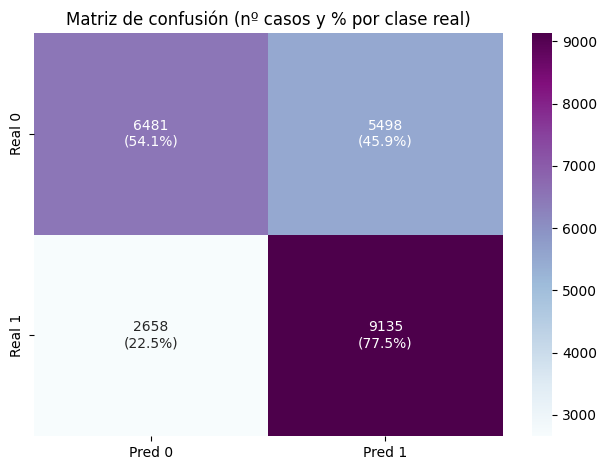

In [ ]:
lgbm_final = LGBMClassifier(
    n_estimators=195, learning_rate=0.041, max_depth=-1, num_leaves=81, max_bins=280,
    random_state=42, min_child_samples=26, reg_alpha=0.3,
    n_jobs=-1, verbose=-1
)

resultado_final = cross_validate(
    lgbm_final, X_train_copy, y_train, cv=10,
    scoring=["accuracy", "precision", "recall", "f1"]
)
print(f"recall: {resultado_final['test_recall'].mean():.4f} | "
      f"precision: {resultado_final['test_precision'].mean():.4f} | "
      f"f1: {resultado_final['test_f1'].mean():.4f} | "
      f"accuracy: {resultado_final['test_accuracy'].mean():.4f}")

lgbm_final.fit(X_train_copy, y_train)
y_pred = lgbm_final.predict(X_test_filtered)
print(classification_report(y_test, y_pred))

# Representamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

etiquetas = np.array([f"{v}\n({p:.1f}%)" for v, p in zip(cm.flatten(), cm_pct.flatten())]).reshape(cm.shape)

sns.heatmap(cm, annot=etiquetas, fmt="", cmap="BuPu", xticklabels=["Pred 0", "Pred 1"], yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de confusión (nº casos y % por clase real)")
plt.tight_layout()
plt.show()

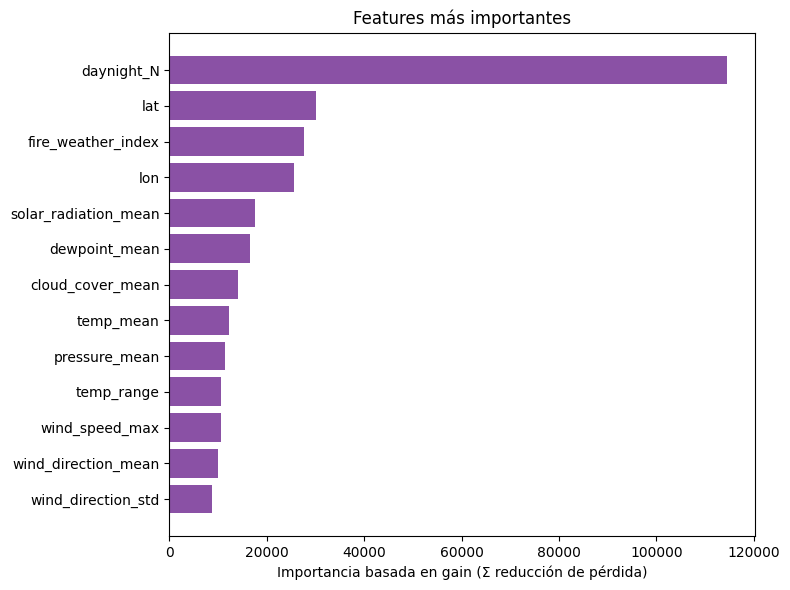

In [37]:
booster = lgbm_final.booster_
feature_importances = pd.DataFrame({
    'feature': booster.feature_name(),
    'importance': booster.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.barh(feature_importances['feature'], feature_importances['importance'], color=plt.cm.BuPu(0.7))
plt.xlabel('Importancia basada en gain (Σ reducción de pérdida)')
plt.title('Features más importantes')
plt.tight_layout()
plt.show()

El porcentaje de verdaderos positivos sube un 0.3% y el de verdaderos negativos se reduce en 0.2% con respecto a la anterior versión del modelo. Estos resultados muestran el efecto contrario al buscado: los falsos positivos no se reducen, sino que son los falsos negativos los que disminuyen ligeramente (unas décimas), a costa de un pequeño aumento en los falsos positivos. Esto indica que, con la arquitectura actual del modelo, la regularización no constituye una palanca efectiva para mejorar la precisión sin perjudicar el recall. Al revisar la importancia de las features, vemos que realmente no hay ninguna variable que aporte un valor despreciable a gain, por lo que tampoco se modifica el dataset de entrada.

Al haber mejorado el número de casos verdaderos detectados, se decide mantener **este modelo como el definitvo para LightGBM**.

**6.2 Optimización de XGBoost**

El **objetivo** de esta sección será optimizar este modelo hasta alcanzar al menos unas métricas similares al LightGBM.

In [38]:
xg_clas = XGBClassifier(random_state=42, n_jobs=-1, verbosity=0)

# --- Etapa 1: búsqueda amplia ---
param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.1, 0.2],
    'max_depth': [3, 5, 9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0.3, 0.5],
}
xg_random = RandomizedSearchCV(xg_clas, param_distributions=param_grid, n_iter=50,
                                scoring="f1", cv=cv_clf, random_state=42, n_jobs=-1, verbose=1)
xg_random.fit(X_train_copy, y_train)
print(xg_random.best_score_, xg_random.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
0.6893329509221712 {'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.3}


In [39]:
# --- Etapa 2: refinamiento acotado alrededor del óptimo ---
param_grid2 = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [9, 14, 20],
    'min_child_weight': [5, 10, 15],
    'gamma': [0.2, 0.3, 0.4],
}
xg_random2 = RandomizedSearchCV(xg_clas, param_distributions=param_grid2, n_iter=50,
                                 scoring="f1", cv=cv_clf, random_state=42, n_jobs=-1, verbose=1)
xg_random2.fit(X_train_copy, y_train)
print(xg_random2.best_score_, xg_random2.best_params_)



Fitting 5 folds for each of 50 candidates, totalling 250 fits
0.6927514712899902 {'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.3}


              precision    recall  f1-score   support

         0.0       0.71      0.54      0.61     11979
         1.0       0.62      0.77      0.69     11793

    accuracy                           0.66     23772
   macro avg       0.67      0.66      0.65     23772
weighted avg       0.67      0.66      0.65     23772



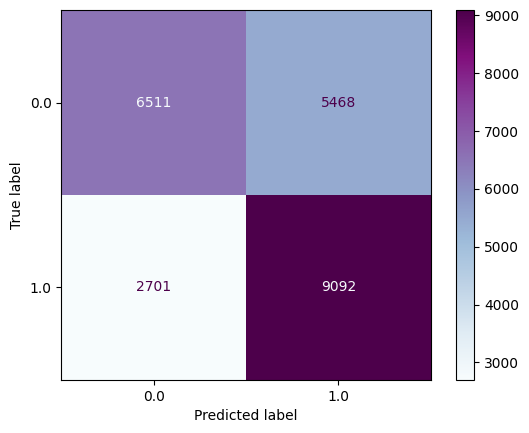

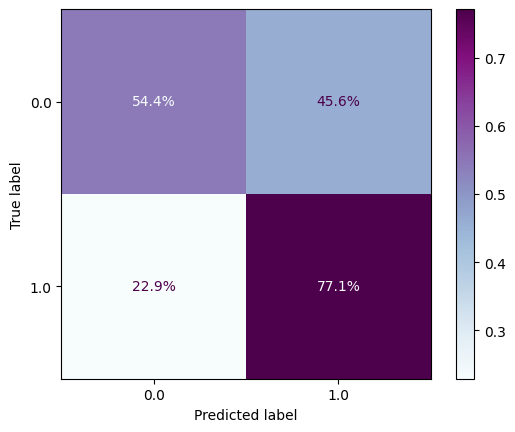

In [ ]:
# --- Evaluación en test con la mejor configuración ---
xg_final = XGBClassifier(
    n_estimators=100, min_child_weight=10, max_depth=9, learning_rate=0.05, gamma=0.3,
    random_state=42, n_jobs=-1, verbosity=0
)
xg_final.fit(X_train_copy, y_train)
y_pred_xg = xg_final.predict(X_test_filtered)

print(classification_report(y_test, y_pred_xg))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xg, cmap="BuPu")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xg, normalize='true', values_format='.1%', cmap="BuPu")

**6.3 Optimización de K-Nearest Neighbor (KNN)**

El **objetivo** de esta sección será optimizar este modelo hasta alcanzar al menos unas métricas similares a los modelos basados en ensembles. Como se trata en este caso de un modelo basado en distancias, para la parte de evaluación final de este modelo se necesitan escalar también los datos de `X_test`.

In [47]:
X_test_scaled = X_test_filtered.copy()
columnas_continuas = [c for c in X_test_scaled.columns if c != col_categorica]
X_test_scaled[columnas_continuas] = spt.transform(X_test_scaled[columnas_continuas])

In [45]:
knn = KNeighborsClassifier()

# --- Etapa 1: búsqueda amplia ---
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31, 45],  # rango amplio, incluyendo valores altos
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
knn_grid = GridSearchCV(knn, param_grid_knn, scoring="f1", cv=cv_clf, n_jobs=-1, verbose=1)
knn_grid.fit(X_train_scaled, y_train)
print("Mejores params KNN:", knn_grid.best_params_)
print("Mejor F1 KNN:", knn_grid.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores params KNN: {'metric': 'manhattan', 'n_neighbors': 45, 'weights': 'distance'}
Mejor F1 KNN: 0.6719116876962052


In [55]:
# --- Etapa 2: refinamiento acotado alrededor del óptimo ---
param_grid_knn_2 = {
    "n_neighbors": [45, 50, 55, 60, 63, 65],
    "weights": ["distance"],
    "metric": ["manhattan"],
}
knn_grid_2 = GridSearchCV(knn, param_grid_knn_2, scoring="f1", cv=cv_clf, n_jobs=-1, verbose=1)
knn_grid_2.fit(X_train_scaled, y_train)
print("Mejores params KNN (refinado):", knn_grid_2.best_params_)
print("Mejor F1 KNN (refinado):", knn_grid_2.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores params KNN (refinado): {'metric': 'manhattan', 'n_neighbors': 63, 'weights': 'distance'}
Mejor F1 KNN (refinado): 0.6735932851166794


              precision    recall  f1-score   support

         0.0       0.68      0.55      0.61     11979
         1.0       0.62      0.74      0.67     11793

    accuracy                           0.64     23772
   macro avg       0.65      0.64      0.64     23772
weighted avg       0.65      0.64      0.64     23772



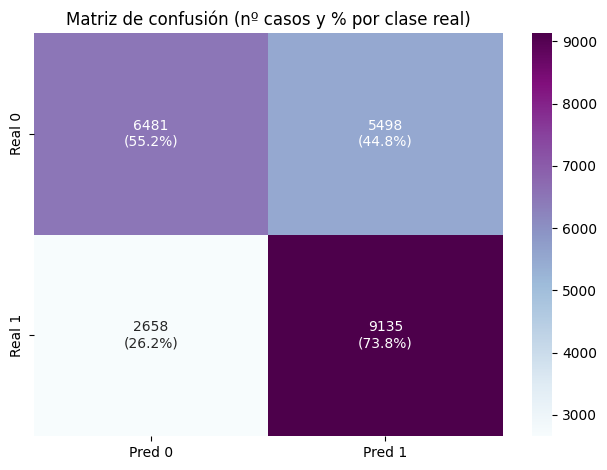

In [56]:
knn_final = KNeighborsClassifier(**knn_grid_2.best_params_)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))

# Representamos la matriz de confusión
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_pct = cm_knn / cm_knn.sum(axis=1, keepdims=True) * 100

etiquetas = np.array([f"{v}\n({p:.1f}%)" for v, p in zip(cm.flatten(), cm_pct.flatten())]).reshape(cm.shape)

sns.heatmap(cm, annot=etiquetas, fmt="", cmap="BuPu", xticklabels=["Pred 0", "Pred 1"], yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de confusión (nº casos y % por clase real)")
plt.tight_layout()
plt.show()

**6.4 Optimización de Logistic Regression**

El **objetivo** de esta sección será optimizar el modelo de regresión logística. Igual que para KNN, en regresión logística usaremos el dataset test estandarizado para hacer la evaluación final.

In [57]:
lr_clas = LogisticRegression(max_iter=1000, random_state=42)

# --- Etapa 1: búsqueda amplia ---
param_grid_lr = {
    "C": [0.01, 0.1, 1, 5, 10, 50, 100],
    "penalty": ["l2"],
    "solver": ["liblinear", "saga"],
}
lr_grid = GridSearchCV(lr_clas, param_grid_lr, scoring="f1", cv=cv_clf, n_jobs=-1, verbose=1)
lr_grid.fit(X_train_scaled, y_train)
print("Mejores params LR:", lr_grid.best_params_)
print("Mejor F1 LR:", lr_grid.best_score_)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Mejores params LR: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Mejor F1 LR: 0.673276068618016


c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [58]:
# --- Etapa 2: refinamiento acotado alrededor del óptimo ---
param_grid_lr_2 = {
    "C": [6, 7, 8, 9, 10],
    "penalty": ["l2"],
    "solver": ["liblinear"],
}
lr_grid_2 = GridSearchCV(lr_clas, param_grid_lr_2, scoring="f1", cv=cv_clf, n_jobs=-1, verbose=1)
lr_grid_2.fit(X_train_scaled, y_train)
print("Mejores params LR (refinado):", lr_grid_2.best_params_)
print("Mejor F1 LR (refinado):", lr_grid_2.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Mejores params LR (refinado): {'C': 6, 'penalty': 'l2', 'solver': 'liblinear'}
Mejor F1 LR (refinado): 0.673276068618016


c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


              precision    recall  f1-score   support

         0.0       0.68      0.49      0.57     11979
         1.0       0.60      0.76      0.67     11793

    accuracy                           0.63     23772
   macro avg       0.64      0.63      0.62     23772
weighted avg       0.64      0.63      0.62     23772



c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


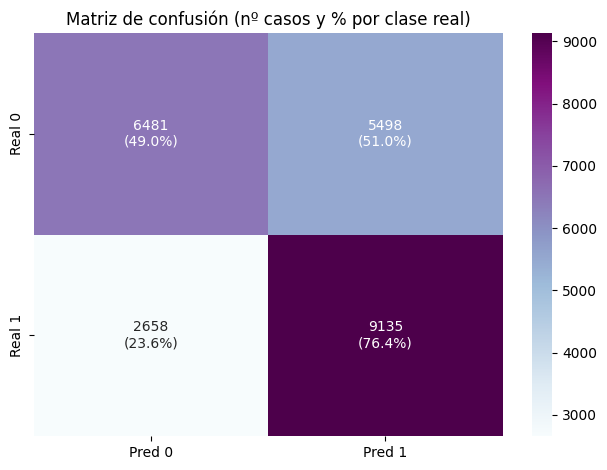

In [65]:
# --- Modelo final con los mejores hiperparámetros encontrados ---
lr_final = LogisticRegression(**lr_grid_2.best_params_, max_iter=1000, random_state=42)
lr_final.fit(X_train_scaled, y_train)

# --- Evaluación en test con el modelo final ---
y_pred_lr = lr_final.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))

# Representamos la matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_pct = cm_lr / cm_lr.sum(axis=1, keepdims=True) * 100

etiquetas = np.array([f"{v}\n({p:.1f}%)" for v, p in zip(cm.flatten(), cm_pct.flatten())]).reshape(cm.shape)

sns.heatmap(cm, annot=etiquetas, fmt="", cmap="BuPu", xticklabels=["Pred 0", "Pred 1"], yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de confusión (nº casos y % por clase real)")
plt.tight_layout()
plt.show()


**6.5 Configuración de VotingClassifier con los modelos anteriores ensamblados**

Para esta última fase, se ensamblan todos los modelos anteriores en un modelo de hard voting, en principio considerando que la votación de todos los modelos contribuye por igual a la decisión final. Para agilizar el código, se utilizará `sklearn.pipeline` para encadenar todos los pasos de transformación y el modelo final en un único objeto.

In [61]:
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline

In [81]:
# --- LR y KNN: incluidos en Pipeline con el escalador, para poder pasarles X_train sin transformar ---
lr_definitive = Pipeline([
    ("scaler", PowerTransformer(method="yeo-johnson", standardize=True)),
    ("clf", lr_final)  
])

knn_definitive= Pipeline([
    ("scaler", PowerTransformer(method="yeo-johnson", standardize=True)),
    ("clf", knn_final) 
])

# --- Ensemble ---
voting_clf = VotingClassifier(
    estimators=[
        ("lgbm", lgbm_final),
        ("xgb", xg_clas),
        ("lr", lr_definitive),
        ("knn", knn_definitive),
    ],
    voting="soft",   # promedia las probabilidades, mejor que voto binario
    n_jobs=-1
)

# --- Validación con el mismo cv_clf de siempre ---
resultado_voting = cross_validate(
    voting_clf, X_train_copy, y_train, cv=cv_clf,
    scoring=["accuracy", "precision", "recall", "f1"]
)

print("Voting Ensemble:")
print(f"  recall: {resultado_voting['test_recall'].mean():.4f} ± {resultado_voting['test_recall'].std():.4f}")
print(f"  precision: {resultado_voting['test_precision'].mean():.4f}")
print(f"  f1: {resultado_voting['test_f1'].mean():.4f}")
print(f"  accuracy: {resultado_voting['test_accuracy'].mean():.4f}")

Voting Ensemble:
  recall: 0.7756 ± 0.0060
  precision: 0.6291
  f1: 0.6947
  accuracy: 0.6583


In [82]:
voting_clf.fit(X_train_copy, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lgbm', ...), ('xgb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,boosting_type,'gbdt'
,num_leaves,81
,max_depth,-1
,learning_rate,0.041
,n_estimators,195


**Conclusión**

El modelo de Voting Ensemble alcanza un recall de 0.7756 (± 0.0060), precisión de 0.6291, F1 de 0.6947 y accuracy de 0.6583. Estos resultados son muy similares a los del mejor modelo individual (LightGBM: recall 0.7688, precisión 0.6300, F1 0.6925, accuracy 0.6578), con una mejora marginal en recall y F1. Se procede a evaluar el modelo sobre el conjunto de test para confirmar su comportamiento antes de considerarlo como candidato definitivo.

### **7. Evaluación final ✓**

              precision    recall  f1-score   support

         0.0       0.71      0.54      0.61     11979
         1.0       0.62      0.78      0.69     11793

    accuracy                           0.66     23772
   macro avg       0.67      0.66      0.65     23772
weighted avg       0.67      0.66      0.65     23772



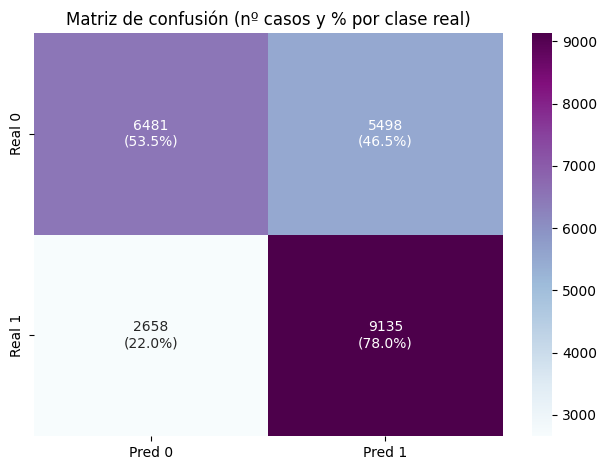

In [83]:
y_pred_voting = voting_clf.predict(X_test_filtered)

print(classification_report(y_test, y_pred_voting))

# Representamos la matriz de confusión
cm_voting = confusion_matrix(y_test, y_pred_voting)
cm_pct = cm_voting / cm_lr.sum(axis=1, keepdims=True) * 100

etiquetas = np.array([f"{v}\n({p:.1f}%)" for v, p in zip(cm.flatten(), cm_pct.flatten())]).reshape(cm.shape)

sns.heatmap(cm, annot=etiquetas, fmt="", cmap="BuPu", xticklabels=["Pred 0", "Pred 1"], yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de confusión (nº casos y % por clase real)")
plt.tight_layout()
plt.show()


**Conclusiones finales y futuras mejoras**

**Conclusiones**

- El modelo final (Voting Classifier) alcanza un **recall del 78% sobre la clase positiva** (precisión: 0.62, F1: 0.69), lo que implica que aproximadamente 1 de cada 5 incendios reales (≈22%) no es detectado por el sistema. Este resultado satisface el criterio de aceptación establecido en la fase de Business Case, que exigía un recall mínimo del 70% para la clase positiva.

- Comparando el modelo final con el mejor modelo individual obtenido (LightGBM: recall 0.7688, precisión 0.6300, F1 0.6925, accuracy 0.6578), las métricas de clasificación a un umbral de decisión de 0.5 resultan **prácticamente equivalentes** entre ambos modelos (diferencias de recall y F1 inferiores a un punto porcentual). El valor añadido del ensemble por votación se concentra, por tanto, en una **mejora marginal del área bajo la curva ROC (AUC)** respecto al mejor modelo individual (ver notebook `model_optimization_evaluation.ipynb` para la visualización de la curva), lo que indica una capacidad de discriminación ligeramente superior en el conjunto de umbrales posibles, aunque esta ventaja no se traduce en una mejora sustancial de las métricas puntuales evaluadas al umbral por defecto.

- El modelo mantiene un **recall del 54% sobre la clase negativa**, cumpliendo el segundo umbral de aceptación definido (superior al 50%). Este equilibrio resulta relevante desde una perspectiva operativa: maximizar la detección de incendios reales sin generar un volumen de falsos positivos que comprometa la asignación eficiente de recursos de extinción, evitando así el patrón de sobrealerta observado en configuraciones más agresivas evaluadas durante la fase de optimización (ver sección de Optimización, modelo `max_depth=2`).

- Dada la similitud de resultados entre el ensemble y el mejor modelo individual, cabe destacar que, en el contexto de este proyecto y con los recursos computacionales disponibles, **LightGBM por sí solo constituye una alternativa prácticamente equivalente en rendimiento**, con la ventaja adicional de un menor coste de inferencia y mayor simplicidad de mantenimiento frente al ensemble completo. La elección entre ambos modelos como definitivo podría depender, por tanto, de consideraciones operativas (latencia, recursos de despliegue) más que de una diferencia sustancial en capacidad predictiva.

**Limitaciones y futuras mejoras:**

- Se observa una **distribución bimodal en las probabilidades predichas** por modelos como LightGBM, parcialmente asociada al desequilibrio en la representación de la variable `daynight_N` dentro del dataset (mayor proporción de observaciones nocturnas frente a diurnas). Ampliar la recogida de datos correspondientes a casos diurnos permitiría equilibrar esta distribución y podría contribuir a una mejor calibración de las probabilidades del modelo.

- El conjunto de features actual se limita a variables meteorológicas de corto plazo (temperatura, humedad, viento, radiación, etc.) y al índice compuesto FWI. La incorporación de **variables ambientales adicionales** —precipitación acumulada, contenido de materia orgánica del suelo, tipo de cobertura vegetal, entre otras— podría capturar interacciones con el target actualmente no representadas en el modelo, incrementando potencialmente el AUC y la capacidad predictiva del conjunto de modelos que integran el ensemble.

- Asimismo, sería recomendable **validar la estabilidad temporal del modelo** mediante un esquema de validación que respete el orden cronológico de los datos (por ejemplo, entrenando con años anteriores y evaluando sobre años posteriores), en lugar de una validación cruzada aleatoria, dado que las condiciones climáticas y de riesgo de incendio pueden presentar tendencias no estacionarias a lo largo del tiempo.

### **8. Persistencia ✓**

Guardamos el modelo entrenado y los transformadores.

In [85]:
import joblib, os
os.makedirs('src/models', exist_ok=True)

joblib.dump(voting_clf, 'src/models/model_final.joblib')
joblib.dump(spt,     'src/models/scaler.joblib')

print("✅ Modelo y preprocesadores guardados en src/models/")

# Verificar carga
model_loaded = joblib.load('src/models/model_final.joblib')
print(f"Modelo cargado: {type(model_loaded).__name__}")

✅ Modelo y preprocesadores guardados en src/models/
Modelo cargado: VotingClassifier
